# Normalized Scanpath Saliency NSS
# Saccadeの回数


In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from voluntary_fixation.envs import EYEMOVE_ROOT
from voluntary_fixation.envs import TR, MOVIE_FPS, EYEMOVE_ROOT, SAVE_ROOT, RUN_VOLUMES, RUN_IDS, MOVIE_WIDTH, MOVIE_HEIGHT, SUBJECT_IDS

from __future__ import annotations
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
from tqdm import tqdm
from voluntary_fixation.dataset.bold_dataset import get_non_overlap_indices_for_concatenate_data
from voluntary_fixation.behavior.src.temporal_alignment_filtering import sacc_cnt_shift_relation_df
from voluntary_fixation.behavior.src.temporal_alignment_filtering import alignment2VOLUME as alignment2VOLUME_Original
from voluntary_fixation.behavior.src.probability import count_gaze_shift_with_saliency
from voluntary_fixation.behavior.src.data_loader import read_csvs
from voluntary_fixation.bold2feat.eval import get_label

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy import stats


import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueTypeフォントを埋め込む
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = ['Arial','DejaVu Sans']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False  # マイナス符号の化け防止


# plt.rcParams['font.family'] = 'Times New Roman' # font familyの設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 20 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 17 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 17 # 軸だけ変更されます
# from voluntary_fixation.behavior.src.temporal_alignment_filtering import sacc_cnt_shift_relation_df, alignment2VOLUME

In [11]:


@dataclass
class Samples:
    s: str
    x: np.ndarray
    y: np.ndarray
    t: np.ndarray

    def window_mask(self, t0: float, t1: float) -> np.ndarray:
        return (self.t >= t0) & (self.t < t1)

def _stack_subjects(subjects: List[Samples], mask_list: Optional[List[np.ndarray]]=None):
    xs, ys, ts = [], [], []
    for i, s in enumerate(subjects):
        m = mask_list[i] if mask_list is not None else slice(None)
        xs.append(s.x[m]); ys.append(s.y[m]); ts.append(s.t[m])
    if len(xs)==0:
        return np.empty((0,)), np.empty((0,)), np.empty((0,))
    return np.concatenate(xs), np.concatenate(ys), np.concatenate(ts)

def _gaussian_scores_at(points_xyz: np.ndarray, train_xyz: np.ndarray, sigma_x: float, sigma_y: float, sigma_t: float) -> np.ndarray:
    if train_xyz.shape[0] == 0 or points_xyz.shape[0] == 0:
        return np.zeros((points_xyz.shape[0],), dtype=np.float64)
    px = points_xyz[:, [0]] / sigma_x; py = points_xyz[:, [1]] / sigma_y; pt = points_xyz[:, [2]] / sigma_t
    tx = train_xyz[:, 0][None, :] / sigma_x; ty = train_xyz[:, 1][None, :] / sigma_y; tt = train_xyz[:, 2][None, :] / sigma_t
    d2 = (px - tx)**2 + (py - ty)**2 + (pt - tt)**2
    return np.exp(-0.5 * d2).sum(axis=1)

def _monte_carlo_normalization_bounds(train_xyz: np.ndarray, margin: Tuple[float,float,float]):
    if train_xyz.shape[0] == 0:
        mins = np.array([0.0, 0.0, 0.0], dtype=np.float64); maxs = np.array([1.0, 1.0, 1.0], dtype=np.float64)
    else:
        mins = train_xyz.min(axis=0); maxs = train_xyz.max(axis=0)
    sx, sy, st = margin
    mins = mins - np.array([sx, sy, st]); maxs = maxs + np.array([sx, sy, st])
    return mins, maxs

def _sample_uniform(mins: np.ndarray, maxs: np.ndarray, n: int, rng: np.random.Generator) -> np.ndarray:
    u = rng.random((n, 3)); return mins + u * (maxs - mins)

def nss_time_extended(subjects: List[Samples], sigma_x: float = 1.2, sigma_y: float = 1.2, sigma_t: float = 26.25,
                      win_ms: float = 225.0, step_ms: float = 25.0, mc_probes: int = 4000, mc_margin: Tuple[float,float,float]=(3.0,3.0,75.0), seed: int = 0):
    rng = np.random.default_rng(seed)
    # 被験者の全サンプルの時間範囲を取得
    t_min = min(s.t.min() if s.t.size else np.inf for s in subjects); t_max = max(s.t.max() if s.t.size else -np.inf for s in subjects)
    if not np.isfinite(t_min) or not np.isfinite(t_max): raise ValueError("No samples provided.")
    # スライディングウィンドウの開始・終了時間を計算
    t0s = np.arange(t_min, t_max - win_ms + 1e-9, step_ms)
    t1s = t0s + win_ms
    # 各被験者ごとに、各ウィンドウに対する時間マスクを事前計算
    subj_masks = []
    for s in subjects:
        masks = [(s.t >= t0) & (s.t < t1) for t0, t1 in zip(t0s, t1s)]; subj_masks.append(masks)
    print('Total windows:', len(t0s))
    rows = []
    for w_idx, (t0, t1) in tqdm(enumerate(zip(t0s, t1s))):
        for k, sk in enumerate(subjects):
            test_mask = subj_masks[k][w_idx]
            # テストサンプルが存在しない場合はスキップ
            if not np.any(test_mask):
                rows.append(dict(t0=t0, t1=t1, subject=k, nss=np.nan, n_test_samples=0)); continue
            # 訓練サンプルをスタック（被験者k以外で作成）
            train_masks = [subj_masks[i][w_idx] if i != k else np.zeros_like(subj_masks[i][w_idx], dtype=bool) for i in range(len(subjects))]
            tx, ty, tt = _stack_subjects(subjects, train_masks); train_xyz = np.stack([tx, ty, tt], axis=1)
            if train_xyz.shape[0] == 0:
                rows.append(dict(t0=t0, t1=t1, subject=k, nss=np.nan, n_test_samples=int(test_mask.sum()))); continue
            # testサンプルを取得
            test_xyz = np.stack([sk.x[test_mask], sk.y[test_mask], sk.t[test_mask]], axis=1)
            # モンテカルロ法による正規化パラメータの計算
            ## mc_margin: 学習サンプルの外側に設けるサンプリング余白（x,y,t各軸）
            ## mc_probes：正規化（平均・分散）推定の精度, 混合ガウス分布Fの統計量の推定が重いのでモンテカルロを行う　（Dorr,2010の実装にはない）
            mins, maxs = _monte_carlo_normalization_bounds(train_xyz, mc_margin); probes = _sample_uniform(mins, maxs, mc_probes, rng)
            F_probes = _gaussian_scores_at(probes, train_xyz, sigma_x, sigma_y, sigma_t); mu = F_probes.mean(); sd = F_probes.std(ddof=0)
            if sd == 0.0:
                print(f"[warn] Window {t0:.1f}-{t1:.1f}ms, subject {k}: sd=0 (train_samples={len(train_xyz)})")
                rows.append(dict(t0=t0, t1=t1, subject=k, nss=np.nan, n_test_samples=int(test_mask.sum()))); continue
            # テストサンプルに対するスコア計算
            F_test = _gaussian_scores_at(test_xyz, train_xyz, sigma_x, sigma_y, sigma_t)
            # 正規化スコア計算
            nss_vals = (F_test - mu) / sd; nss = float(nss_vals.mean())
            rows.append(dict(t0=t0, t1=t1, subject=k, nss=nss, n_test_samples=int(test_mask.sum())))
    df = pd.DataFrame(rows)
    meta = dict(sigma_x=sigma_x, sigma_y=sigma_y, sigma_t=sigma_t, win_ms=win_ms, step_ms=step_ms, mc_probes=mc_probes, mc_margin=mc_margin, seed=seed)
    return df, meta


def get_eyetrack_df(sub_id, run_id):
    eyetrack_fn = f'sub-{sub_id}/sub-{sub_id}_task-movie_run-{run_id}_events.tsv'
    eyetrack_path = os.path.join('../../', EYEMOVE_ROOT, eyetrack_fn)
    eyetrack = pd.read_table(eyetrack_path)
    return eyetrack

def get_saliency_df(run_id):
    # movieのsaliencyのデータを取得
    saliency_path = os.path.join('../../', SAVE_ROOT, 'saliency/deepgaze2e_predict', f'segment{run_id}.csv')
    saliency_df = pd.read_csv(saliency_path)
    return saliency_df

def find_idx_of_specific_onset_offset(df, start, end, offset=False)->np.ndarray:
    onsets = df['t0'].values
    if offset:
        offsets = df['t1'].values
        idx = np.where((start <= offsets) & (offsets<=end))[0]
        # idx = np.where((start <= onsets) & (offsets<=end))[0]

    else:
        idx = np.where((start <= onsets) & (onsets<=end))[0]
    return idx

def alignment2VOLUME(df:pd.DataFrame, run_id:int, agg:str='sum')->pd.DataFrame:
    num_sample_per_run = RUN_VOLUMES[run_id-1]
    columns = list(df.columns)
    new_df = {col:[] for col in columns}
    for i in range(num_sample_per_run):
        onset = i * TR
        offset = onset + TR
        idx = find_idx_of_specific_onset_offset(df, onset, offset)
        if agg == 'sum':
            agg_df = df.iloc[idx].sum()
        elif agg == 'mean':
            agg_df = df.iloc[idx].mean()
        else:
            raise ValueError('agg should be sum or mean')
        for col in columns:
            new_df[col].append(agg_df[col])
    new_df = pd.DataFrame(new_df)
    return new_df




File already exists: ../../../../results/voluntary_fixation/NSS/check_nss_saliency_run1_win250_step125_100_100_160.0.csv, skipping computation.
subj: 01 n_fixations: 2187 n_points: 12022
subj: 02 n_fixations: 3572 n_points: 21260
subj: 03 n_fixations: 3124 n_points: 20824
subj: 04 n_fixations: 3612 n_points: 21186
subj: 06 n_fixations: 3835 n_points: 20500
subj: 10 n_fixations: 3785 n_points: 20299
subj: 14 n_fixations: 2966 n_points: 21160
subj: 15 n_fixations: 3678 n_points: 20463
subj: 16 n_fixations: 1850 n_points: 10858
subj: 17 n_fixations: 3524 n_points: 21736
subj: 18 n_fixations: 3553 n_points: 21986
subj: 19 n_fixations: 3247 n_points: 21879
Computing NSS scores with parameters:
win_ms: 250, step_ms: 125.0, sigma_x: 100, sigma_y: 100, sigma_t: 160.0
Total windows: 7055


7055it [02:48, 41.96it/s]


subj: 01 n_fixations: 3960 n_points: 21801
subj: 02 n_fixations: 3443 n_points: 20948
subj: 03 n_fixations: 3052 n_points: 20620
subj: 04 n_fixations: 3470 n_points: 20125
subj: 06 n_fixations: 3794 n_points: 19970
subj: 10 n_fixations: 3323 n_points: 18039
subj: 14 n_fixations: 2772 n_points: 20764
subj: 15 n_fixations: 3904 n_points: 21732
subj: 16 n_fixations: 3482 n_points: 22201
subj: 17 n_fixations: 3464 n_points: 20900
subj: 18 n_fixations: 3588 n_points: 21721
subj: 19 n_fixations: 3128 n_points: 21838
Computing NSS scores with parameters:
win_ms: 250, step_ms: 125.0, sigma_x: 100, sigma_y: 100, sigma_t: 160.0
Total windows: 7007


7007it [03:08, 37.16it/s]


subj: 01 n_fixations: 4375 n_points: 24233
subj: 02 n_fixations: 3910 n_points: 23824
subj: 03 n_fixations: 3822 n_points: 23582
subj: 04 n_fixations: 3061 n_points: 17480
subj: 06 n_fixations: 4318 n_points: 23106
subj: 10 n_fixations: 4374 n_points: 24250
subj: 14 n_fixations: 3269 n_points: 22426
subj: 15 n_fixations: 4367 n_points: 24313
subj: 16 n_fixations: 3527 n_points: 20211
subj: 17 n_fixations: 4023 n_points: 23464
subj: 18 n_fixations: 3731 n_points: 24047
subj: 19 n_fixations: 3784 n_points: 24278
Computing NSS scores with parameters:
win_ms: 250, step_ms: 125.0, sigma_x: 100, sigma_y: 100, sigma_t: 160.0
Total windows: 7807


...

7023it [03:07, 37.43it/s]


subj: 01 n_fixations: 4649 n_points: 26679
subj: 02 n_fixations: 4534 n_points: 26195
subj: 03 n_fixations: 3900 n_points: 25546
subj: 04 n_fixations: 3654 n_points: 21229
subj: 06 n_fixations: 4663 n_points: 24652
subj: 10 n_fixations: 4423 n_points: 22746
subj: 14 n_fixations: 3615 n_points: 24612
subj: 15 n_fixations: 4822 n_points: 27274
subj: 16 n_fixations: 4640 n_points: 28078
subj: 17 n_fixations: 4183 n_points: 25957
subj: 18 n_fixations: 4274 n_points: 26801
subj: 19 n_fixations: 4220 n_points: 27322
Computing NSS scores with parameters:
win_ms: 250, step_ms: 125.0, sigma_x: 100, sigma_y: 100, sigma_t: 160.0
Total windows: 8680


8680it [03:52, 37.38it/s]


subj: 01 n_fixations: 2825 n_points: 16942
subj: 02 n_fixations: 2618 n_points: 16611
subj: 03 n_fixations: 2433 n_points: 16877
subj: 04 n_fixations: 2688 n_points: 15369
subj: 06 n_fixations: 2988 n_points: 16375
subj: 10 n_fixations: 3016 n_points: 15561
subj: 14 n_fixations: 2176 n_points: 15561
subj: 15 n_fixations: 2876 n_points: 16930
subj: 16 n_fixations: 2789 n_points: 16951
subj: 17 n_fixations: 2541 n_points: 16311
subj: 18 n_fixations: 2537 n_points: 16575
subj: 19 n_fixations: 2438 n_points: 16977
Computing NSS scores with parameters:
win_ms: 250, step_ms: 125.0, sigma_x: 100, sigma_y: 100, sigma_t: 160.0
Total windows: 5387


5387it [02:30, 35.90it/s]


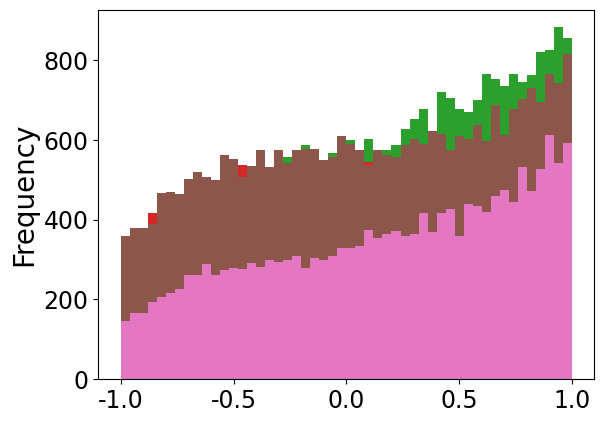

In [23]:

FIXATION_LABEL = ['PURS', 'FIXA']
resample_fs = 25 # 1000Hz以下
fs_ms = 1000 / resample_fs # ms

win_ms = 250 # 2000
step_ms = win_ms / 2
sigma_x = 100 # 視野角の半径100の1/3 # 100
sigma_y = 100 # 視野角の半径100の1/3 # 100
sigma_t = fs_ms * 4 # 4フレーム分の時間幅 # 500

for run_id in RUN_IDS:
    df_path = os.path.join('../../', SAVE_ROOT, 'NSS', f'check_nss_saliency_run{run_id}_win{int(win_ms)}_step{int(step_ms)}_{sigma_x}_{sigma_y}_{sigma_t}.csv')
    if os.path.exists(df_path):
        print(f'File already exists: {df_path}, skipping computation.')
        continue
    saliency_df = get_saliency_df(run_id=run_id)
    # create subject list
    subj_list = []
    for sub_id in SUBJECT_IDS:
        eyetrack = get_eyetrack_df(sub_id, run_id)
        eyetrack_fixations = eyetrack[eyetrack['label'].isin(FIXATION_LABEL)]
        xs, ys, ts = [], [], []
        for i, row in eyetrack_fixations.iterrows():
            duration = row['duration'] * 1000
            t_Start = row['onset'] * 1000
            t_End = t_Start + duration
            n_points = int(np.ceil(duration / fs_ms))
            t = np.linspace(t_Start, t_End, n_points)
            if n_points > 1:
                x = np.interp(t, [t_Start, t_End], [row['start_x'], row['end_x']])
                y = np.interp(t, [t_Start, t_End], [row['start_y'], row['end_y']])
            else:
                x = np.array([row['start_x']])
                y = np.array([row['start_y']])
            assert len(x) == len(y) == len(t), f"Length mismatch: {len(x)}, {len(y)}, {len(t)}"
            xs += x.tolist()
            ys += y.tolist()
            ts += t.tolist()
        subj_list.append(Samples(s=sub_id, x=np.array(xs), y=np.array(ys), t=np.array(ts)))

        # print('max duration:', duration.max(), 'min duration:', duration.min())
        print('subj:', sub_id, 'n_fixations:', len(eyetrack_fixations), 'n_points:', len(xs))


    print('Computing NSS scores with parameters:')
    print(f'win_ms: {win_ms}, step_ms: {step_ms}, sigma_x: {sigma_x}, sigma_y: {sigma_y}, sigma_t: {sigma_t}')
    df, meta = nss_time_extended(
        subj_list,
        sigma_x=sigma_x, sigma_y=sigma_y, sigma_t=sigma_t,
        # win_ms=225.0, step_ms=75.0,
        win_ms=win_ms, step_ms=step_ms,
        mc_probes=4000, mc_margin=(30, 30, 75.0), seed=0
    )
    os.makedirs(os.path.dirname(df_path), exist_ok=True)
    df.to_csv(df_path, index=False)
    df['nss'].plot.hist(bins=50, range=(-1, 1))


In [22]:
# FIXATION_LABEL = ['PURS', 'FIXA']
# resample_fs = 25 # 1000Hz以下
# fs_ms = 1000 / resample_fs # ms

# win_ms = 250 # 2000
# step_ms = win_ms / 2
# sigma_x = 100 # 33.3 # 視野角の半径100の1/3 # 100
# sigma_y = 100 # 33.3 # 視野角の半径100の1/3 # 100
# sigma_t = fs_ms * 4 # 4フレーム分の時間幅 # 500

sbj_df_list = {
    sbj_id: [] for sbj_id in SUBJECT_IDS
}

# NSS df の用意
for run_id in RUN_IDS:
    original_df = pd.read_csv(os.path.join('../../', SAVE_ROOT, 'NSS', f'check_nss_saliency_run{run_id}_win{int(win_ms)}_step{int(step_ms)}_{sigma_x}_{sigma_y}_{sigma_t}.csv'))

    for s, sbj_id in enumerate((SUBJECT_IDS)):
        sbj_df = original_df[original_df['subject'] == s]
        print(f'sbj{sbj_id}', sbj_df.columns)
        sbj_df.dropna(inplace=True, axis=0)
        sbj_df['t0'] = sbj_df['t0'] / 1000.0
        sbj_df['t1'] = sbj_df['t1'] / 1000.0
        aligned_df = alignment2VOLUME(sbj_df, run_id=run_id, agg='mean')
        sbj_df_list[sbj_id].append(aligned_df)
for sbj_id in SUBJECT_IDS:
    sbj_df_list[sbj_id] = pd.concat(sbj_df_list[sbj_id], axis=0, ignore_index=True)
sbj_df_list['01']['nss'].plot.hist(bins=50, range=(-1, 1))

sbj01 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj02 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_1080625/983102892.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_1080625/983102892.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_1080625/983102892.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

sbj03 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj04 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_1080625/983102892.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_1080625/983102892.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_1080625/983102892.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

sbj06 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj10 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


...

sbj16 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj17 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_1080625/983102892.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_1080625/983102892.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_1080625/983102892.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

sbj18 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj19 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_1080625/983102892.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_1080625/983102892.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_1080625/983102892.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

FileNotFoundError: [Errno 2] No such file or directory: '../../../../results/voluntary_fixation/NSS/check_nss_saliency_run2_win250_step125_100_100_160.0.csv'

non overlap test indices 3598 815
Index(['iou_q', 'saliency_TR_q', 'iou_th', 'sal_upper_th', 'sal_lower_th'], dtype='object')
    iou_q  saliency_TR_q    iou_th  sal_upper_th  sal_lower_th
42    0.5            0.7  0.312469   1057.732985    424.850136
424.8501357814248 1057.7329848865415
../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/01-FIXA_PURS_q0.5-sal_q0.9.csv is already exist
../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/01-FIXA_PURS_q0.5-sal_q0.9.csv is already exist
sbj01  th2:  0.31246855875
sbj01 zero: 210
sbj01 saliency_th_upper_train:  1057.7329848865415
sbj01 saliency_th_lower_train:  424.8501357814248
label1:: gaze shift with saliency shift and small iou
	 TRAIN:: 408. TEST:: 137
label2:: gaze shift without saliency shift and small iou
	 TRAIN:: 259. TEST:: 98
../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/02-FIXA_PURS_q0.5-sal_q0.9.csv is already exist
sbj02  th2:  0.31246855875
sbj02 zero: 28
sbj02 saliency_th_

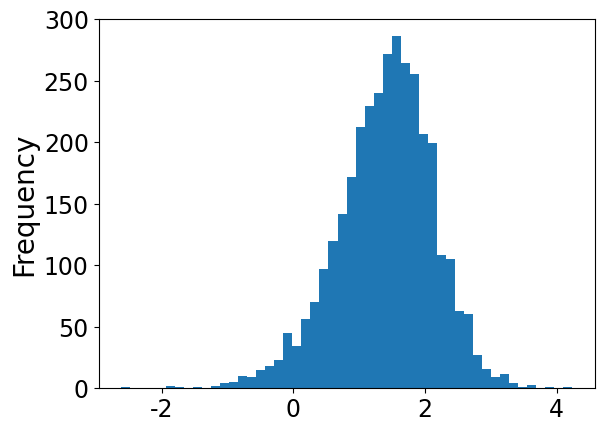

nss_all_sbj shape: (12, 815)
max w_sal_in_tests 813
max wo_sal_in_tests 814
nss_dict w_sal_gaze shape: (12,)
nss_dict wo_sal_gaze shape: (12,)


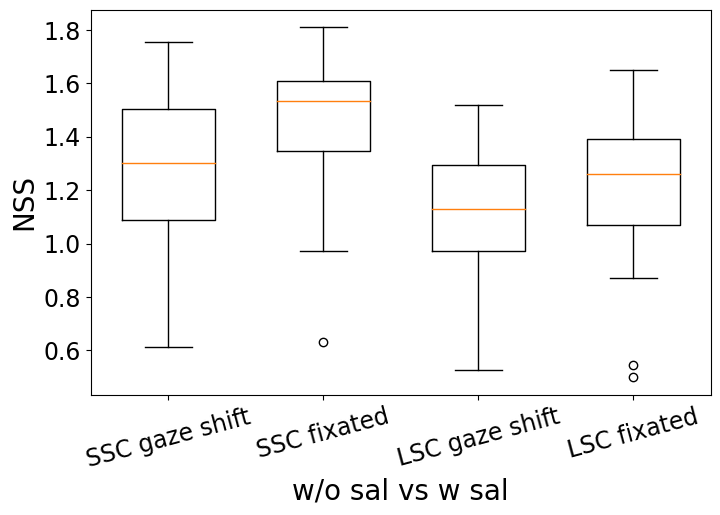

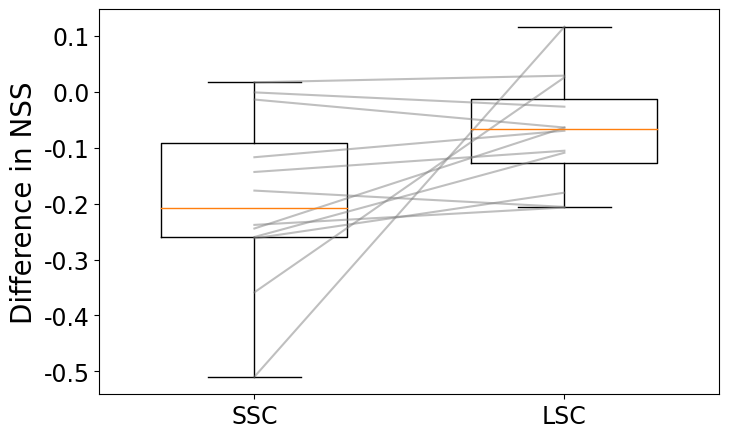

TtestResult(statistic=-2.0980535548704693, pvalue=0.05980148669051105, df=11)
/home/kazu/shared_response/figures/fig1/NSS_difference.pdf


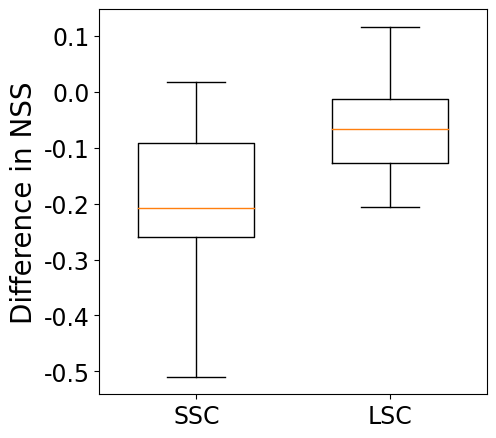

                  sum_sq    df         F    PR(>F)
C(sal)          0.443666   1.0  3.567470  0.065525
C(gaze)         0.208511   1.0  1.676615  0.202129
C(sal):C(gaze)  0.043670   1.0  0.351145  0.556499
Residual        5.472035  44.0       NaN       NaN
sal: eta2= 0.07193172511727093 partial eta2= 0.07499811222028101
gaze: eta2= 0.03380597356862493 partial eta2= 0.03670620186285855
inter: eta2= 0.007080216926458818 partial eta2= 0.007917382759012152
nss_all_sbj shape: (12, 815)
max w_sal_in_tests 813
sbj: 01 len wo_sal gaze / nogaze: 98 195 len w_sal gaze /nogaze: 137 139
sbj: 02 len wo_sal gaze / nogaze: 117 176 len w_sal gaze /nogaze: 151 125
sbj: 03 len wo_sal gaze / nogaze: 122 171 len w_sal gaze /nogaze: 137 139
sbj: 04 len wo_sal gaze / nogaze: 116 177 len w_sal gaze /nogaze: 141 135
sbj: 06 len wo_sal gaze / nogaze: 109 184 len w_sal gaze /nogaze: 132 144
sbj: 10 len wo_sal gaze / nogaze: 123 170 len w_sal gaze /nogaze: 144 132
sbj: 14 len wo_sal gaze / nogaze: 127 166 len w_sa

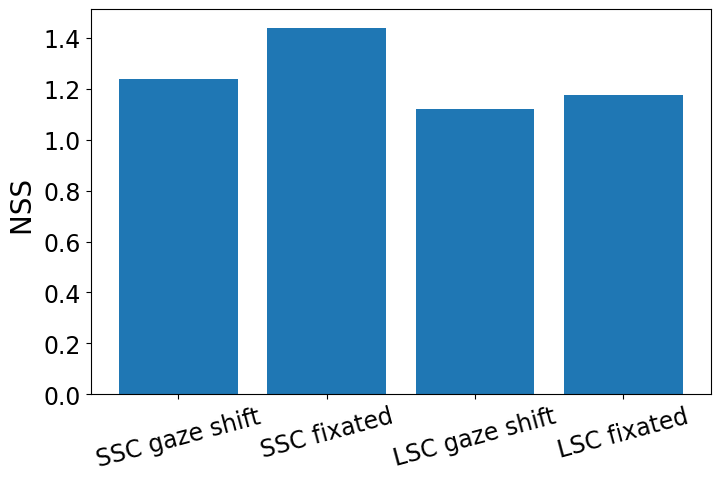

                     sum_sq      df          F        PR(>F)
C(sal)            64.007149     1.0  96.847025  1.067409e-22
C(gaze)           27.892551     1.0  42.203264  8.817381e-11
C(sal):C(gaze)     8.463970     1.0  12.806543  3.478546e-04
Residual        4421.486629  6690.0        NaN           NaN
sal: eta2= 0.01415507920741489 partial eta2= 0.014269811154613675
gaze: eta2= 0.006168393280587106 partial eta2= 0.006268863558950904
inter: eta2= 0.001871793513454089 partial eta2= 0.0019106240283287437


In [58]:

prefix_dir = '../'
gaze_shift_label = ['FIXA', 'PURS']

non_overlap_train_indices, non_overlap_test_indices = get_non_overlap_indices_for_concatenate_data('segment', jupyter=True)
print('non overlap test indices', non_overlap_test_indices.max(), len(non_overlap_test_indices))
# get label
frame_offset = 0
delay = 0
mask_offset = 0
n_components = 250
modality = 'masked_image'
sampling_mode = 'segment'
remove_str = '-remove_brightness' #+'-remove_empty_eyetrack'
saliency_label = 'avg_shift_norm'

remove_empty_eyetrack = False
label_mode = 11.63
saliency_TR_q = 0.7
iou_q = 0.5

# threshold取得
grand_quantile_path = '../../../results/voluntary_fixation/behavior/grand_quantiles.csv'
grand_quantiles_df = pd.read_csv(grand_quantile_path)
print(grand_quantiles_df.columns)
target_th = grand_quantiles_df.query(f'saliency_TR_q=={saliency_TR_q}').query(f'iou_q=={iou_q}')
sal_upper_th = target_th['sal_upper_th'].values[0]
sal_lower_th = target_th['sal_lower_th'].values[0]
print(target_th)
print(sal_lower_th, sal_upper_th)

# label取得
w_sal_in_tests = {}
wo_sal_in_tests = {}

# labelの用意
saliency_dir = os.path.join(prefix_dir, SAVE_ROOT, 'saliency', 'deepgaze2e_predict')
eyemovement_dir = os.path.join(prefix_dir, EYEMOVE_ROOT)
eyemovement_q = 0.5
saliency_q = 0.9
gaze_shift_label = ['FIXA', 'PURS']
use_large_cnt = False
if use_large_cnt:
    lc_str = '_large'
else:
    lc_str = ''



# saliency

sal_df_sbj = {}
eye_df_sbj = {}
dummy_sbj_id = SUBJECT_IDS[0]
saliency_eyetrack_path = os.path.join(prefix_dir, SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                    f'{dummy_sbj_id}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
if os.path.exists(saliency_eyetrack_path):
    print(f'{saliency_eyetrack_path} is already exist')
    saliency_eyetrack_df = pd.read_csv(saliency_eyetrack_path)
    for label in ['max_shift_norm', 'avg_shift_norm']:
        if f'SACC_cnt_with{lc_str}_lower_sal_{label}' in saliency_eyetrack_df.columns:
            saliency_eyetrack_df = saliency_eyetrack_df.rename(columns={f'SACC_cnt_with{lc_str}_lower_sal_{label}':f'SACC_cnt{lc_str}_with_lower_sal_{label}'})


for sbj in SUBJECT_IDS:
    iou_path = os.path.join('../', SAVE_ROOT, 'mask', f'resolution{TR}-start{frame_offset}', 'iou',
                            f'sub-{sbj}.csv')
    pred_and_gt_dir = os.path.join('../', SAVE_ROOT, 'bold2feat_strict_ree2', f'delay{delay}-fo{frame_offset}-mo{mask_offset}',
                                    f'pca{n_components}-{modality}-{sampling_mode}{remove_str}', sbj)

    saliency_eyetrack_path = os.path.join('../', SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                            f'{sbj}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
    eye_tracking_exist_flag_dir = os.path.join('../', SAVE_ROOT, 'features', f'pooled_{modality}-tr{TR}-fo{frame_offset}-mo{mask_offset}', sbj)
    w_sal_in_train, w_sal_in_test, wo_sal_in_train, wo_sal_in_test = get_label(iou_path, saliency_eyetrack_path, EYEMOVE_ROOT, saliency_dir, sampling_mode, eye_tracking_exist_flag_dir,
                                                                                saliency_label,
                                                                                iou_q, eyemovement_q, saliency_q, sbj, gaze_shift_label, delay,
                                                                                remove_empty_eyetrack, use_large_cnt=use_large_cnt,
                                                                                label_mode=label_mode, saliency_TR_q=saliency_TR_q, jupyter=True)
    w_sal_in_tests[sbj] = w_sal_in_test
    wo_sal_in_tests[sbj] = wo_sal_in_test


# saliency testデータのみ
saliency_shift = saliency_eyetrack_df['avg_shift_norm'].to_numpy()
saliency_shift = saliency_shift[non_overlap_test_indices]

sbj_df_list['01']['nss'].plot.hist(bins=50)
plt.show()
nss_all_sbj = np.stack([sbj_df_list[sbj_id]['nss'].to_numpy() for sbj_id in SUBJECT_IDS], axis=0)
nss_all_sbj = nss_all_sbj[:, non_overlap_test_indices]

wo_sal_indices = np.where(saliency_shift <= sal_lower_th)[0]
w_sal_indices = np.where(saliency_shift > sal_upper_th)[0]

print('nss_all_sbj shape:', nss_all_sbj.shape)  # (num_subjects, num_timepoints
print('max w_sal_in_tests', max(w_sal_in_test))
print('max wo_sal_in_tests', max(wo_sal_in_test))
nss_dict = {'sbj':[], 'w_sal_gaze':[], 'wo_sal_gaze':[], 'w_sal_no_gaze':[], 'wo_sal_no_gaze':[]}
for s, sbj_id in enumerate((SUBJECT_IDS)):
    w_sal_in_test = w_sal_in_tests[sbj_id]
    wo_sal_in_test = wo_sal_in_tests[sbj_id]
    wo_sal_in_test_nogaze = [i for i in wo_sal_indices if not i in wo_sal_in_test]
    w_sal_in_test_nogaze = [i for i in w_sal_indices if not i in w_sal_in_test]

    sbj_wo_sal_nogaze = nss_all_sbj[s, wo_sal_in_test_nogaze]
    sbj_wo_sal = nss_all_sbj[s, wo_sal_in_test]
    sbj_w_sal_nogaze = nss_all_sbj[s, w_sal_in_test_nogaze]
    sbj_w_sal = nss_all_sbj[s, w_sal_in_test]
    nss_dict['sbj'].append(sbj_id)
    nss_dict['w_sal_gaze'].append(np.nanmean(sbj_w_sal))
    nss_dict['wo_sal_gaze'].append(np.nanmean(sbj_wo_sal))
    nss_dict['w_sal_no_gaze'].append(np.nanmean(sbj_w_sal_nogaze))
    nss_dict['wo_sal_no_gaze'].append(np.nanmean(sbj_wo_sal_nogaze))
print('nss_dict w_sal_gaze shape:', np.array(nss_dict['w_sal_gaze']).shape)
print('nss_dict wo_sal_gaze shape:', np.array(nss_dict['wo_sal_gaze']).shape)

wo_sal_gaze_sbj = np.array(nss_dict['wo_sal_gaze'])
w_sal_gaze_sbj = np.array(nss_dict['w_sal_gaze'])
wo_sal_no_gaze_sbj = np.array(nss_dict['wo_sal_no_gaze'])
w_sal_no_gaze_sbj = np.array(nss_dict['w_sal_no_gaze'])

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
plt.boxplot([wo_sal_gaze_sbj, wo_sal_no_gaze_sbj, w_sal_gaze_sbj, w_sal_no_gaze_sbj], positions=[0, 1, 2, 3], widths=0.6)
axes.set_xlabel('w/o sal vs w sal')
axes.set_ylabel('NSS')
axes.set_xticks([0, 1, 2, 3])
axes.set_xticklabels(['SSC gaze shift', 'SSC fixated', 'LSC gaze shift', 'LSC fixated'], rotation=15)
plt.show()


wo_sal_ratio = wo_sal_gaze_sbj-wo_sal_no_gaze_sbj # wo_sal_gaze_sbj/wo_sal_no_gaze_sbj
w_sal_ratio = w_sal_gaze_sbj-w_sal_no_gaze_sbj # w_sal_gaze_sbj/w_sal_no_gaze_sbj

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
plt.boxplot([wo_sal_ratio, w_sal_ratio], positions=[0, 1], widths=0.6)
for i in range(len(wo_sal_ratio)):
    axes.plot([0, 1], [wo_sal_ratio[i], w_sal_ratio[i]], color='gray', alpha=0.5)
# axes.set_xlabel('w/o sal vs w sal')
axes.set_ylabel('Difference in NSS')
axes.set_xticks([0, 1])
axes.set_xticklabels(['SSC', 'LSC'], rotation=0)
plt.show()
print(stats.ttest_rel(wo_sal_ratio, w_sal_ratio))

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
plt.boxplot([wo_sal_ratio, w_sal_ratio], positions=[0, 1], widths=0.6)
axes.set_ylabel('Difference in NSS')
axes.set_xticks([0, 1])
axes.set_xticklabels(['SSC', 'LSC'], rotation=0)
savepath = os.path.join('/home/kazu/shared_response/figures', 'fig1', 'NSS_difference.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)
plt.show()




# ==== データ整形 ====
a1b1 =nss_dict['w_sal_gaze']
a1b2 =nss_dict['w_sal_no_gaze']
a2b1 =nss_dict['wo_sal_gaze']
a2b2 =nss_dict['wo_sal_no_gaze']
y = np.concatenate([a1b1, a1b2, a2b1, a2b2])
A = (["w_sal"] * len(a1b1)) + (["w_sal"] * len(a1b2)) + (["wo_sal"] * len(a2b1)) + (["wo_sal"] * len(a2b2))
B = (["gaze"] * len(a1b1)) + (["no_gaze"] * len(a1b2)) + (["gaze"] * len(a2b1)) + (["no_gaze"] * len(a2b2))


df1 = pd.DataFrame({"y": y, "sal": A, "gaze": B})

# ==== 二元配置分散分析（交互作用を含む一般的なモデル）====
# 対応なしの独立群デザインなので OLS でOK
model = smf.ols("y ~ C(sal) * C(gaze)", data=df1).fit()
anova_table = anova_lm(model, typ=2)  # typ=2 が一般的（不均衡デザインにも比較的頑健）
print(anova_table)
SS_sal = anova_table['sum_sq']['C(sal)']
SS_gaze = anova_table['sum_sq']['C(gaze)']
SS_inter = anova_table['sum_sq']['C(sal):C(gaze)']
SS_res = anova_table['sum_sq']['Residual']

eta2_sal = SS_sal / (SS_sal + SS_gaze + SS_inter + SS_res)
eta2_gaze = SS_gaze / (SS_sal + SS_gaze + SS_inter + SS_res)
eta2_inter = SS_inter / (SS_sal + SS_gaze + SS_inter + SS_res)

partial_eta2_sal = SS_sal / (SS_sal + SS_res)
partial_eta2_gaze = SS_gaze / (SS_gaze + SS_res)
partial_eta2_inter = SS_inter / (SS_inter + SS_res)


print('sal: eta2=', eta2_sal, 'partial eta2=', partial_eta2_sal)
print('gaze: eta2=', eta2_gaze, 'partial eta2=', partial_eta2_gaze)
print('inter: eta2=', eta2_inter, 'partial eta2=', partial_eta2_inter)


# 被験者 flatten

nss_all_sbj = np.stack([sbj_df_list[sbj_id]['nss'].to_numpy() for sbj_id in SUBJECT_IDS], axis=0)
nss_all_sbj = nss_all_sbj[:, non_overlap_test_indices]
print('nss_all_sbj shape:', nss_all_sbj.shape)  # (num_subjects, num_timepoints
print('max w_sal_in_tests', max(w_sal_in_test))
nss_dict = {'sbj':[], 'w_sal_gaze':[], 'wo_sal_gaze':[], 'w_sal_no_gaze':[], 'wo_sal_no_gaze':[]}
for s, sbj_id in enumerate((SUBJECT_IDS)):
    w_sal_in_test = w_sal_in_tests[sbj_id]
    wo_sal_in_test = wo_sal_in_tests[sbj_id]
    wo_sal_in_test_nogaze = [i for i in wo_sal_indices if not i in wo_sal_in_test]
    w_sal_in_test_nogaze = [i for i in w_sal_indices if not i in w_sal_in_test]
    print('sbj:', sbj_id, 'len wo_sal gaze / nogaze:', len(wo_sal_in_test), len(wo_sal_in_test_nogaze), 'len w_sal gaze /nogaze:', len(w_sal_in_test), len(w_sal_in_test_nogaze))

    sbj_wo_sal_nogaze = nss_all_sbj[s, wo_sal_in_test_nogaze]
    sbj_wo_sal = nss_all_sbj[s, wo_sal_in_test]
    sbj_w_sal_nogaze = nss_all_sbj[s, w_sal_in_test_nogaze]
    sbj_w_sal = nss_all_sbj[s, w_sal_in_test]
    nss_dict['sbj'].append(sbj_id)
    nss_dict['w_sal_gaze'].append(sbj_w_sal)
    nss_dict['wo_sal_gaze'].append(sbj_wo_sal)
    nss_dict['w_sal_no_gaze'].append(sbj_w_sal_nogaze)
    nss_dict['wo_sal_no_gaze'].append(sbj_wo_sal_nogaze)

w_sal_gaze_mean= np.nanmean(np.concatenate(nss_dict['w_sal_gaze'], axis=0))
wo_sal_gaze_mean = np.nanmean(np.concatenate(nss_dict['wo_sal_gaze'], axis=0))
w_sal_no_gaze_mean = np.nanmean(np.concatenate(nss_dict['w_sal_no_gaze'], axis=0))
wo_sal_no_gaze_mean = np.nanmean(np.concatenate(nss_dict['wo_sal_no_gaze'], axis=0))


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
plt.bar([0,1,2,3], [wo_sal_gaze_mean, wo_sal_no_gaze_mean, w_sal_gaze_mean, w_sal_no_gaze_mean])
# axes.set_xlabel('w/o sal vs w sal')
axes.set_ylabel('NSS ')
axes.set_xticks([0, 1, 2, 3])
axes.set_xticklabels(['SSC gaze shift', 'SSC fixated', 'LSC gaze shift', 'LSC fixated'], rotation=15)
plt.show()



# from scipy import stats
# t_stat, p_val = stats.ttest_ind(nss_dict['wo_sal_gaze'], nss_dict['w_sal_gaze'], equal_var=False)

# print("t値:", t_stat)
# print("p値:", p_val)




# ==== データ整形 ====
a1b1 = np.concatenate(nss_dict['w_sal_gaze'])
a1b2 = np.concatenate(nss_dict['w_sal_no_gaze'])
a2b1 = np.concatenate(nss_dict['wo_sal_gaze'])
a2b2 = np.concatenate(nss_dict['wo_sal_no_gaze'])
y = np.concatenate([a1b1, a1b2, a2b1, a2b2])
A = (["w_sal"] * len(a1b1)) + (["w_sal"] * len(a1b2)) + (["wo_sal"] * len(a2b1)) + (["wo_sal"] * len(a2b2))
B = (["gaze"] * len(a1b1)) + (["no_gaze"] * len(a1b2)) + (["gaze"] * len(a2b1)) + (["no_gaze"] * len(a2b2))

df = pd.DataFrame({"y": y, "sal": A, "gaze": B})

# ==== 二元配置分散分析（交互作用を含む一般的なモデル）====
# 対応なしの独立群デザインなので OLS でOK
model = smf.ols("y ~ C(sal) * C(gaze)", data=df).fit()
anova_table = anova_lm(model, typ=2)  # typ=2 が一般的（不均衡デザインにも比較的頑健）
print(anova_table)
SS_sal = anova_table['sum_sq']['C(sal)']
SS_gaze = anova_table['sum_sq']['C(gaze)']
SS_inter = anova_table['sum_sq']['C(sal):C(gaze)']
SS_res = anova_table['sum_sq']['Residual']

eta2_sal = SS_sal / (SS_sal + SS_gaze + SS_inter + SS_res)
eta2_gaze = SS_gaze / (SS_sal + SS_gaze + SS_inter + SS_res)
eta2_inter = SS_inter / (SS_sal + SS_gaze + SS_inter + SS_res)

partial_eta2_sal = SS_sal / (SS_sal + SS_res)
partial_eta2_gaze = SS_gaze / (SS_gaze + SS_res)
partial_eta2_inter = SS_inter / (SS_inter + SS_res)


print('sal: eta2=', eta2_sal, 'partial eta2=', partial_eta2_sal)
print('gaze: eta2=', eta2_gaze, 'partial eta2=', partial_eta2_gaze)
print('inter: eta2=', eta2_inter, 'partial eta2=', partial_eta2_inter)


In [28]:
wo_sal_gaze_sbj/wo_sal_no_gaze_sbj

array([0.84196568, 0.92730566, 0.99957168, 0.87059643, 1.0273918 ,
       0.63056158, 0.99160801, 0.60796185, 0.82769319, 0.9083617 ,
       0.84543582, 0.85523373])

In [ ]:
# <<<< 声runが固定されていておかしい
# # create subject list
# subj_list = []
# for sub_id in SUBJECT_IDS:
#     eyetrack = get_eyetrack_df(sub_id, run_id)
#     eyetrack_fixations = eyetrack[eyetrack['label'].isin(FIXATION_LABEL)]
#     xs, ys, ts = [], [], []
#     for i, row in eyetrack_fixations.iterrows():
#         duration = row['duration'] * 1000
#         t_Start = row['onset'] * 1000
#         t_End = t_Start + duration
#         n_points = int(np.ceil(duration / fs_ms))
#         t = np.linspace(t_Start, t_End, n_points)
#         if n_points > 1:
#            x = np.interp(t, [t_Start, t_End], [row['start_x'], row['end_x']])
#            y = np.interp(t, [t_Start, t_End], [row['start_y'], row['end_y']])
#         else:
#            x = np.array([row['start_x']])
#            y = np.array([row['start_y']])
#         assert len(x) == len(y) == len(t), f"Length mismatch: {len(x)}, {len(y)}, {len(t)}"
#         xs += x.tolist()
#         ys += y.tolist()
#         ts += t.tolist()
#     subj_list.append(Samples(s=sub_id, x=np.array(xs), y=np.array(ys), t=np.array(ts)))

#     # print('max duration:', duration.max(), 'min duration:', duration.min())
#     print('subj:', sub_id, 'n_fixations:', len(eyetrack_fixations), 'n_points:', len(xs))



In [7]:

FIXATION_LABEL = ['PURS', 'FIXA']
resample_fs = 25 # 1000Hz以下
fs_ms = 1000 / resample_fs # ms

win_ms = 500 # 2000
step_ms = win_ms / 2
sigma_x = 100 # 33.3 # 33.3 # 視野角の半径100の1/3 # 100
sigma_y = 100 # 33.3 # 33.3 # 視野角の半径100の1/3 # 100
sigma_t = fs_ms * 4 # 4フレーム分の時間幅 # 500

sbj_df_list = {
    sbj_id: [] for sbj_id in SUBJECT_IDS
}

# NSS df の用意
for run_id in RUN_IDS:
    original_df = pd.read_csv(f'/home/kazu/shared_response/results/20251103/check_nss_saliency_run{run_id}_win{int(win_ms)}_step{int(step_ms)}_{sigma_x}_{sigma_y}_{sigma_t}.csv')

    for s, sbj_id in enumerate((SUBJECT_IDS)):
        sbj_df = original_df[original_df['subject'] == s]
        print(f'sbj{sbj_id}', sbj_df.columns)
        sbj_df.dropna(inplace=True, axis=0)
        sbj_df['t0'] = sbj_df['t0'] / 1000.0
        sbj_df['t1'] = sbj_df['t1'] / 1000.0
        aligned_df = alignment2VOLUME(sbj_df, run_id=run_id, agg='mean')
        sbj_df_list[sbj_id].append(aligned_df)
for sbj_id in SUBJECT_IDS:
    sbj_df_list[sbj_id] = pd.concat(sbj_df_list[sbj_id], axis=0, ignore_index=True)
sbj_df_list['01']['nss'].plot.hist(bins=50, range=(-1, 1))

# labelの用意
eyemovement_q = 0.5
saliency_q = 0.9
gaze_shift_label = ['FIXA', 'PURS']
use_large_cnt = False
if use_large_cnt:
    lc_str = '_large'
else:
    lc_str = ''

prefix_dir = '../'

saliency_dir = os.path.join(prefix_dir, SAVE_ROOT, 'saliency', 'deepgaze2e_predict')
eyemovement_dir = os.path.join(prefix_dir, EYEMOVE_ROOT)
sal_df_sbj = {}
eye_df_sbj = {}
for sbj_id in SUBJECT_IDS:
    saliency_eyetrack_path = os.path.join(prefix_dir, SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                        f'{sbj_id}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
    if os.path.exists(saliency_eyetrack_path):
        print(f'{saliency_eyetrack_path} is already exist')
        saliency_eyetrack_df = pd.read_csv(saliency_eyetrack_path)
        for label in ['max_shift_norm', 'avg_shift_norm']:
            if f'SACC_cnt_with{lc_str}_lower_sal_{label}' in saliency_eyetrack_df.columns:
                saliency_eyetrack_df = saliency_eyetrack_df.rename(columns={f'SACC_cnt_with{lc_str}_lower_sal_{label}':f'SACC_cnt{lc_str}_with_lower_sal_{label}'})
    else:
        os.makedirs(os.path.dirname(saliency_eyetrack_path), exist_ok=True)
        print('saliency_eyetrack_df is not exist. Creating...')
        saliency_eyetrack_df_list = []
        idx_offsets = np.cumsum([0] + RUN_VOLUMES)
        for run_id in tqdm(RUN_IDS):
            saliency_csv_file_path = os.path.join(prefix_dir, saliency_dir, f'segment{run_id}.csv')
            original_eyetrack_path = os.path.join(prefix_dir, eyemovement_dir,  f'sub-{sbj_id}/sub-{sbj_id}_task-movie_run-{run_id}_events.tsv')
            # get saliency and eyemovement
            saliency_df, original_eyetrack_df = read_csvs(saliency_csv_file_path, original_eyetrack_path,
                                                        gaze_shift_label, video_width=MOVIE_WIDTH,
                                                        video_height=MOVIE_HEIGHT, fps=MOVIE_FPS)
            original_eyetrack_df['power'] = original_eyetrack_df['diff_x']**2 + original_eyetrack_df['diff_y']**2
            # time alignment eyetracking data to saliency data
            saliency_eyetrack_df = sacc_cnt_shift_relation_df(saliency_df,
                                                            original_eyetrack_df,
                                                            gaze_shift_label,
                                                            eyemovement_q, have_duration=False)
            # cnt sal with saliency
            saliency_eyetrack_df = count_gaze_shift_with_saliency(saliency_eyetrack_df, saliency_q)
            # time alignment saliency_eyetrack_df to VOLUME
            saliency_eyetrack_df = alignment2VOLUME_Original(saliency_eyetrack_df, run_id, agg='sum')
            assert len(saliency_eyetrack_df) == RUN_VOLUMES[run_id-1], f'len(saliency_df)={len(saliency_eyetrack_df)}, RUN_VOLUMES[run_id-1]={RUN_VOLUMES[run_id-1]}'
            idx_in_exp = list(np.arange(RUN_VOLUMES[run_id-1]) + idx_offsets[run_id-1])
            saliency_eyetrack_df['idx_in_exp'] = idx_in_exp
            saliency_eyetrack_df_list.append(saliency_eyetrack_df)
        saliency_eyetrack_df = pd.concat(saliency_eyetrack_df_list, axis=0)

    eyetrack_df_list = []
    for run_id in tqdm(RUN_IDS):
        idx_offsets = np.cumsum([0] + RUN_VOLUMES)
        original_eyetrack_path = os.path.join(prefix_dir ,EYEMOVE_ROOT,  f'sub-{sbj_id}/sub-{sbj_id}_task-movie_run-{run_id}_events.tsv')
        # get eyemovement
        _, original_eyetrack_df = read_csvs(None, original_eyetrack_path,
                                                    gaze_shift_label, video_width=MOVIE_WIDTH,
                                                    video_height=MOVIE_HEIGHT, fps=MOVIE_FPS)
        original_eyetrack_df.drop(columns=['label'], inplace=True)
        original_eyetrack_df = alignment2VOLUME_Original(original_eyetrack_df, run_id, agg='mean')
        assert len(original_eyetrack_df) == RUN_VOLUMES[run_id-1], f'len(original_eyetrack_Df_df)={len(original_eyetrack_df)}, RUN_VOLUMES[run_id-1]={RUN_VOLUMES[run_id-1]}'
        idx_in_exp = list(np.arange(RUN_VOLUMES[run_id-1]) + idx_offsets[run_id-1])
        original_eyetrack_df['idx_in_exp'] = idx_in_exp
        eyetrack_df_list.append(original_eyetrack_df)

    eyetrack_df = pd.concat(eyetrack_df_list, axis=0)
    eyetrack_df.set_index('idx_in_exp', inplace=True)

    sal_df_sbj[sbj_id] = saliency_eyetrack_df
    eye_df_sbj[sbj_id] = eyetrack_df

FileNotFoundError: [Errno 2] No such file or directory: '/home/kazu/shared_response/results/20251103/check_nss_saliency_run1_win500_step250_100_100_160.0.csv'

In [2]:
# testデータのみ
saliency_shift = saliency_eyetrack_df['avg_shift_norm'].to_numpy()

non_overlap_train_indices, non_overlap_test_indices = get_non_overlap_indices_for_concatenate_data('segment', jupyter=True)
print(len(non_overlap_train_indices), len(non_overlap_test_indices))

grand_quantile_path = '../../../results/voluntary_fixation/behavior/grand_quantiles.csv'
grand_quantiles_df = pd.read_csv(grand_quantile_path)
print(grand_quantiles_df.columns)
target_th = grand_quantiles_df.query('iou_q==0.5' and 'saliency_TR_q==0.7')
sal_upper_th = target_th['sal_upper_th'].values[0]
sal_lower_th = target_th['sal_lower_th'].values[0]
print(sal_lower_th, sal_upper_th)



nss_all_sbj = np.stack([sbj_df_list[sbj_id]['nss'].to_numpy() for sbj_id in SUBJECT_IDS], axis=0)
print('nss_all_sbj shape:', nss_all_sbj.shape)  # (num_subjects, num_timepoints)
nss_all_sbj = nss_all_sbj[:, non_overlap_test_indices]
saliency_shift = saliency_shift[non_overlap_test_indices]

# 全被験者存在するsampleのインデックスを取得
mean_nss = []
saliency_shift_valid = []
for i in range(len(nss_all_sbj[0])):
    if np.isnan(nss_all_sbj[:, i]).any():
        continue
    mean_nss.append(np.mean(nss_all_sbj[:, i]))
    saliency_shift_valid.append(saliency_shift[i])
print('mean_nss vs saliency', np.corrcoef(mean_nss, saliency_shift_valid)[0, 1])
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
ax.scatter(np.log10(saliency_shift_valid), mean_nss)
ax.set_xlabel('saliency shift')
ax.set_ylabel('Mean NSS')
plt.show()


mean_nss = np.array(mean_nss)
saliency_shift_valid_log = np.log10(np.array(saliency_shift_valid))
sal_interval = 0.1
max_sal = int(np.round(np.max(saliency_shift_valid_log)))
min_sal = int(np.round(np.min(saliency_shift_valid_log)))
num_bins = int((max_sal - min_sal) / sal_interval)
rets_nss = [0 for i in range(num_bins)]


bin_Starts = []
for i in range(num_bins):
    s = min_sal + i * sal_interval
    bin_Starts.append(s)
    idx = np.where((saliency_shift_valid_log >= s) & (saliency_shift_valid_log < s+sal_interval))[0]
    if len(idx) == 0:
        continue
    rets_nss[i] = mean_nss[idx]


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
ax.bar(bin_Starts, [np.mean(x) for x in rets_nss], width=0.8*sal_interval)
ax.vlines(np.log10(sal_lower_th), ymin=0, ymax=5,color='red', linestyle='--')
ax.vlines(np.log10(sal_upper_th), ymin=0, ymax=5,color='red', linestyle='--')
ax.set_xlabel('saliency shift (log10)')
ax.set_ylabel('Bin-wise mean NSS')
plt.show()



rets_nss = [0,0]
# below lower th
lower_idx = np.where((saliency_shift_valid <= sal_lower_th))[0]
# above upper th
upper_idx = np.where((saliency_shift_valid >= sal_upper_th))[0]
print('lower:', len(lower_idx), 'upper:', len(upper_idx))
rets_nss[0] = mean_nss[lower_idx]
rets_nss[1] = mean_nss[upper_idx]
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
axes.bar([0, 1], [np.nanmean(x) for x in rets_nss], width=0.8)
axes.set_xlabel('saliency shift')
axes.set_ylabel('Bin-wise mean NSS')
axes.set_xticks([0, 1])
axes.set_xticklabels(['Lower than \n30percentile', 'Higher than \n70percentile'])
plt.show()



NameError: name 'saliency_eyetrack_df' is not defined

../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/01-FIXA_PURS_q0.5-sal_q0.9.csv is already exist
sbj01  th2:  0.2254584748333333
sbj01 zero: 210
sbj01 saliency_th_upper_train:  1057.7329848865415
sbj01 saliency_th_lower_train:  424.8501357814248
label1:: gaze shift with saliency shift and small iou
	 TRAIN:: 225. TEST:: 86
label2:: gaze shift without saliency shift and small iou
	 TRAIN:: 139. TEST:: 56
../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/02-FIXA_PURS_q0.5-sal_q0.9.csv is already exist
sbj02  th2:  0.2254584748333333
sbj02 zero: 28
sbj02 saliency_th_upper_train:  1057.7329848865415
sbj02 saliency_th_lower_train:  424.8501357814248
label1:: gaze shift with saliency shift and small iou
	 TRAIN:: 282. TEST:: 91
label2:: gaze shift without saliency shift and small iou
	 TRAIN:: 193. TEST:: 73
../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/03-FIXA_PURS_q0.5-sal_q0.9.csv is already exist
sbj03  th2:  0.2254584748333333
sbj0

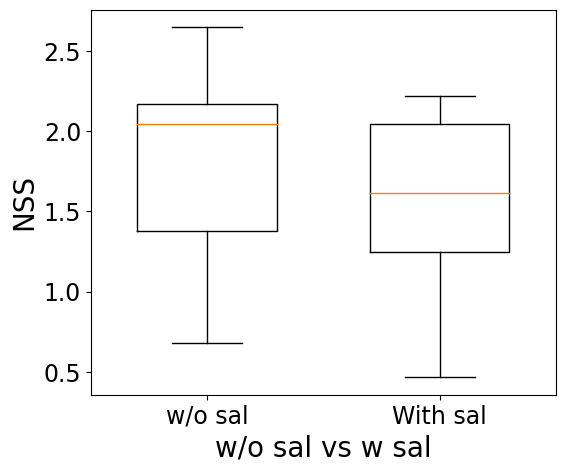

nss_all_sbj shape: (12, 815)
max w_sal_in_tests 809
max w_sal_in_tests 812
max wo_sal_in_tests 813
max w_sal_in_tests 812
max wo_sal_in_tests 813
max w_sal_in_tests 812
max wo_sal_in_tests 813
max w_sal_in_tests 812
max wo_sal_in_tests 813
max w_sal_in_tests 809
max wo_sal_in_tests 813
max w_sal_in_tests 812
max wo_sal_in_tests 813
max w_sal_in_tests 812
max wo_sal_in_tests 813
max w_sal_in_tests 812
max wo_sal_in_tests 813
max w_sal_in_tests 812
max wo_sal_in_tests 813
max w_sal_in_tests 812
max wo_sal_in_tests 813
max w_sal_in_tests 812
max wo_sal_in_tests 813
max w_sal_in_tests 809
max wo_sal_in_tests 813
nss_dict w_sal shape: ()
nss_dict wo_sal shape: ()


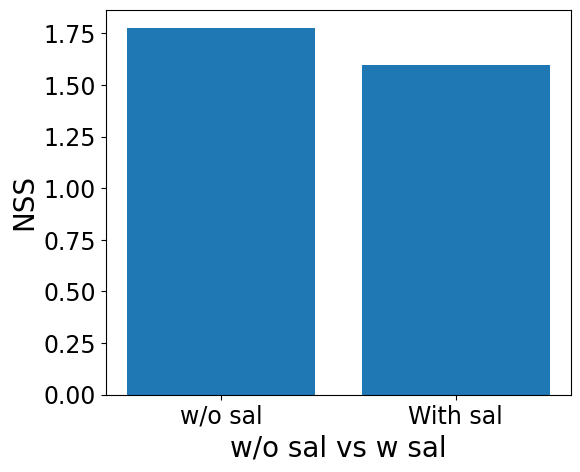

t値: nan
p値: nan


/home/kazu/envs/srm_env/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1103: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/home/kazu/envs/srm_env/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1103: RuntimeWarning: invalid value encountered in double_scalars
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


In [119]:
# get label
frame_offset = 0
delay = -1
mask_offset = 0
n_components = 250
modality = 'masked_image'
sampling_mode = 'segment'
remove_str = '-remove_brightness' # +'-remove_empty_eyetrack'
saliency_label = 'avg_shift_norm'

remove_empty_eyetrack = False
label_mode = 11.63
saliency_TR_q = 0.7
iou_q = 0.3

w_sal_in_tests = {}
wo_sal_in_tests = {}
for sbj in SUBJECT_IDS:
    iou_path = os.path.join('../', SAVE_ROOT, 'mask', f'resolution{TR}-start{frame_offset}', 'iou',
                            f'sub-{sbj}.csv')
    pred_and_gt_dir = os.path.join('../', SAVE_ROOT, 'bold2feat_strict_ree2', f'delay{delay}-fo{frame_offset}-mo{mask_offset}',
                                    f'pca{n_components}-{modality}-{sampling_mode}{remove_str}', sbj)

    saliency_eyetrack_path = os.path.join('../', SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                            f'{sbj}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
    eye_tracking_exist_flag_dir = os.path.join('../', SAVE_ROOT, 'features', f'pooled_{modality}-tr{TR}-fo{frame_offset}-mo{mask_offset}', sbj)
    w_sal_in_train, w_sal_in_test, wo_sal_in_train, wo_sal_in_test = get_label(iou_path, saliency_eyetrack_path, EYEMOVE_ROOT, saliency_dir, sampling_mode, eye_tracking_exist_flag_dir,
                                                                                saliency_label,
                                                                                iou_q, eyemovement_q, saliency_q, sbj, gaze_shift_label, delay,
                                                                                remove_empty_eyetrack, use_large_cnt=use_large_cnt,
                                                                                label_mode=label_mode, saliency_TR_q=saliency_TR_q, jupyter=True)
    w_sal_in_tests[sbj] = w_sal_in_test
    wo_sal_in_tests[sbj] = wo_sal_in_test




nss_all_sbj = np.stack([sbj_df_list[sbj_id]['nss'].to_numpy() for sbj_id in SUBJECT_IDS], axis=0)
nss_all_sbj = nss_all_sbj[:, non_overlap_test_indices]
print('nss_all_sbj shape:', nss_all_sbj.shape)  # (num_subjects, num_timepoints
print('max w_sal_in_tests', max(w_sal_in_test))
nss_dict = {'sbj':[], 'w_sal':[], 'wo_sal':[]}
for s, sbj_id in enumerate((SUBJECT_IDS)):
    w_sal_in_test = w_sal_in_tests[sbj_id]
    print('max w_sal_in_tests', max(w_sal_in_test))
    sbj_w_sal = nss_all_sbj[s, w_sal_in_test]
    wo_sal_in_test = wo_sal_in_tests[sbj_id]
    print('max wo_sal_in_tests', max(wo_sal_in_test))
    sbj_wo_sal = nss_all_sbj[s, wo_sal_in_test]
    nss_dict['sbj'].append(sbj_id)
    nss_dict['w_sal'].append(np.nanmean(sbj_w_sal))
    nss_dict['wo_sal'].append(np.nanmean(sbj_wo_sal))
print('nss_dict w_sal shape:', np.array(nss_dict['w_sal']).shape)
print('nss_dict wo_sal shape:', np.array(nss_dict['wo_sal']).shape)

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
plt.boxplot([nss_dict['wo_sal'], nss_dict['w_sal']], positions=[0, 1], widths=0.6)
axes.set_xlabel('w/o sal vs w sal')
axes.set_ylabel('NSS')
axes.set_xticks([0, 1])
axes.set_xticklabels(['w/o sal', 'With sal'])
plt.show()

nss_all_sbj = np.stack([sbj_df_list[sbj_id]['nss'].to_numpy() for sbj_id in SUBJECT_IDS], axis=0)
nss_all_sbj = nss_all_sbj[:, non_overlap_test_indices]
print('nss_all_sbj shape:', nss_all_sbj.shape)  # (num_subjects, num_timepoints
print('max w_sal_in_tests', max(w_sal_in_test))
nss_dict = {'sbj':[], 'w_sal':[], 'wo_sal':[]}
for s, sbj_id in enumerate((SUBJECT_IDS)):
    w_sal_in_test = w_sal_in_tests[sbj_id]
    print('max w_sal_in_tests', max(w_sal_in_test))
    sbj_w_sal = nss_all_sbj[s, w_sal_in_test]
    wo_sal_in_test = wo_sal_in_tests[sbj_id]
    print('max wo_sal_in_tests', max(wo_sal_in_test))
    sbj_wo_sal = nss_all_sbj[s, wo_sal_in_test]
    nss_dict['sbj'].append(sbj_id)
    nss_dict['w_sal'].append(sbj_w_sal)
    nss_dict['wo_sal'].append(sbj_wo_sal)

nss_dict['w_sal'] = np.nanmean(np.concatenate(nss_dict['w_sal'], axis=0))
nss_dict['wo_sal'] = np.nanmean(np.concatenate(nss_dict['wo_sal'], axis=0))
print('nss_dict w_sal shape:', nss_dict['w_sal'].shape)
print('nss_dict wo_sal shape:', nss_dict['wo_sal'].shape)

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
plt.bar([0,1], [nss_dict['wo_sal'], nss_dict['w_sal']])
axes.set_xlabel('w/o sal vs w sal')
axes.set_ylabel('NSS')
axes.set_xticks([0, 1])
axes.set_xticklabels(['w/o sal', 'With sal'])
plt.show()


from scipy import stats
t_stat, p_val = stats.ttest_ind(nss_dict['wo_sal'], nss_dict['w_sal'], equal_var=False)

print("t値:", t_stat)
print("p値:", p_val)






sbj01 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj02 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_78954/4139742976.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_78954/4139742976.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_78954/4139742976.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

sbj03 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj04 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_78954/4139742976.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_78954/4139742976.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_78954/4139742976.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

sbj06 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj10 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


...

sbj16 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj17 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_78954/4139742976.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_78954/4139742976.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_78954/4139742976.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

sbj18 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj19 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_78954/4139742976.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_78954/4139742976.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_78954/4139742976.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<Axes: ylabel='Frequency'>

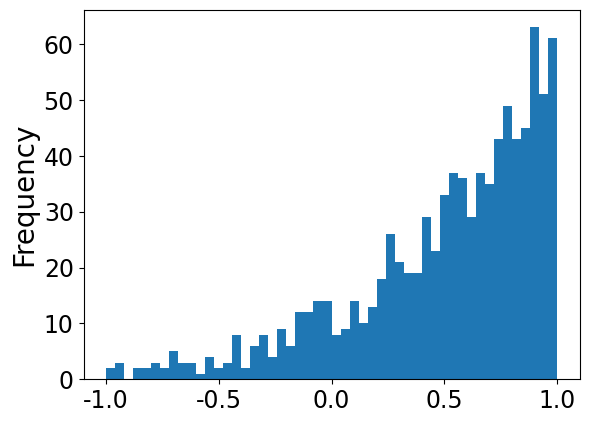

In [10]:
FIXATION_LABEL = ['PURS', 'FIXA']
resample_fs = 25 # 1000Hz以下
fs_ms = 1000 / resample_fs # ms

win_ms = 250 # 2000
step_ms = win_ms / 2
sigma_x = 100 # 33.3 # 視野角の半径100の1/3 # 100
sigma_y = 100 # 33.3 # 視野角の半径100の1/3 # 100
sigma_t = fs_ms * 4 # 4フレーム分の時間幅 # 500

sbj_df_list = {
    sbj_id: [] for sbj_id in SUBJECT_IDS
}

# NSS df の用意
for run_id in RUN_IDS:
    original_df = pd.read_csv(f'/home/kazu/shared_response/results/20251103/check_nss_saliency_run{run_id}_win{int(win_ms)}_step{int(step_ms)}_{sigma_x}_{sigma_y}_{sigma_t}.csv')

    for s, sbj_id in enumerate((SUBJECT_IDS)):
        sbj_df = original_df[original_df['subject'] == s]
        print(f'sbj{sbj_id}', sbj_df.columns)
        sbj_df.dropna(inplace=True, axis=0)
        sbj_df['t0'] = sbj_df['t0'] / 1000.0
        sbj_df['t1'] = sbj_df['t1'] / 1000.0
        aligned_df = alignment2VOLUME(sbj_df, run_id=run_id, agg='mean')
        sbj_df_list[sbj_id].append(aligned_df)
for sbj_id in SUBJECT_IDS:
    sbj_df_list[sbj_id] = pd.concat(sbj_df_list[sbj_id], axis=0, ignore_index=True)
sbj_df_list['01']['nss'].plot.hist(bins=50, range=(-1, 1))



In [16]:

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy import stats

non_overlap_train_indices, non_overlap_test_indices = get_non_overlap_indices_for_concatenate_data('segment', jupyter=True)
print('non overlap test indices', non_overlap_test_indices.max(), len(non_overlap_test_indices))
# get label
frame_offset = 0
delay = 0
mask_offset = 0
n_components = 250
modality = 'masked_image'
sampling_mode = 'segment'
remove_str = '-remove_brightness' #+'-remove_empty_eyetrack'
saliency_label = 'avg_shift_norm'

remove_empty_eyetrack = False
label_mode = 11.63
saliency_TR_q = 0.7
iou_q = 0.5

# threshold取得
grand_quantile_path = os.path.join('../../', SAVE_ROOT, 'behavior', 'grand_quantiles.csv')
grand_quantiles_df = pd.read_csv(grand_quantile_path)
print(grand_quantiles_df.columns)
target_th = grand_quantiles_df.query(f'saliency_TR_q=={saliency_TR_q}').query(f'iou_q=={iou_q}')
sal_upper_th = target_th['sal_upper_th'].values[0]
sal_lower_th = target_th['sal_lower_th'].values[0]
print(target_th)
print(sal_lower_th, sal_upper_th)

# label取得
w_sal_in_tests = {}
wo_sal_in_tests = {}

# labelの用意
saliency_dir = os.path.join('../../', SAVE_ROOT, 'saliency', 'deepgaze2e_predict')
eyemovement_dir = os.path.join('../../', EYEMOVE_ROOT)
eyemovement_q = 0.5
saliency_q = 0.9
gaze_shift_label = ['FIXA', 'PURS']
use_large_cnt = False
if use_large_cnt:
    lc_str = '_large'
else:
    lc_str = ''

prefix_dir = '../'
gaze_shift_label = ['FIXA', 'PURS']

# saliency

sal_df_sbj = {}
eye_df_sbj = {}
dummy_sbj_id = SUBJECT_IDS[0]
saliency_eyetrack_path = os.path.join(prefix_dir, SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                    f'{dummy_sbj_id}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
if os.path.exists(saliency_eyetrack_path):
    print(f'{saliency_eyetrack_path} is already exist')
    saliency_eyetrack_df = pd.read_csv(saliency_eyetrack_path)
    for label in ['max_shift_norm', 'avg_shift_norm']:
        if f'SACC_cnt_with{lc_str}_lower_sal_{label}' in saliency_eyetrack_df.columns:
            saliency_eyetrack_df = saliency_eyetrack_df.rename(columns={f'SACC_cnt_with{lc_str}_lower_sal_{label}':f'SACC_cnt{lc_str}_with_lower_sal_{label}'})


for sbj in SUBJECT_IDS:
    iou_path = os.path.join('../../', SAVE_ROOT, 'mask', f'resolution{TR}-start{frame_offset}', 'iou',
                            f'sub-{sbj}.csv')
    pred_and_gt_dir = os.path.join('../../', SAVE_ROOT, 'bold2feat_strict_ree2', f'delay{delay}-fo{frame_offset}-mo{mask_offset}',
                                    f'pca{n_components}-{modality}-{sampling_mode}{remove_str}', sbj)

    saliency_eyetrack_path = os.path.join('../../', SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                            f'{sbj}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
    eye_tracking_exist_flag_dir = os.path.join('../../', SAVE_ROOT, 'features', f'pooled_{modality}-tr{TR}-fo{frame_offset}-mo{mask_offset}', sbj)
    w_sal_in_train, w_sal_in_test, wo_sal_in_train, wo_sal_in_test = get_label(iou_path, saliency_eyetrack_path, EYEMOVE_ROOT, saliency_dir, sampling_mode, eye_tracking_exist_flag_dir,
                                                                                saliency_label,
                                                                                iou_q, eyemovement_q, saliency_q, sbj, gaze_shift_label, delay,
                                                                                remove_empty_eyetrack, use_large_cnt=use_large_cnt,
                                                                                label_mode=label_mode, saliency_TR_q=saliency_TR_q, jupyter=True)
    w_sal_in_tests[sbj] = w_sal_in_test
    wo_sal_in_tests[sbj] = wo_sal_in_test


# saliency testデータのみ
saliency_shift = saliency_eyetrack_df['avg_shift_norm'].to_numpy()
saliency_shift = saliency_shift[non_overlap_test_indices]

sbj_df_list['01']['nss'].plot.hist(bins=50)
plt.show()
nss_all_sbj = np.stack([sbj_df_list[sbj_id]['nss'].to_numpy() for sbj_id in SUBJECT_IDS], axis=0)
nss_all_sbj = nss_all_sbj[:, non_overlap_test_indices]

wo_sal_indices = np.where(saliency_shift <= sal_lower_th)[0]
w_sal_indices = np.where(saliency_shift > sal_upper_th)[0]

print('nss_all_sbj shape:', nss_all_sbj.shape)  # (num_subjects, num_timepoints
print('max w_sal_in_tests', max(w_sal_in_test))
print('max wo_sal_in_tests', max(wo_sal_in_test))
nss_dict = {'sbj':[], 'w_sal_gaze':[], 'wo_sal_gaze':[], 'w_sal_no_gaze':[], 'wo_sal_no_gaze':[]}
for s, sbj_id in enumerate((SUBJECT_IDS)):
    w_sal_in_test = w_sal_in_tests[sbj_id]
    wo_sal_in_test = wo_sal_in_tests[sbj_id]
    wo_sal_in_test_nogaze = [i for i in wo_sal_indices if not i in wo_sal_in_test]
    w_sal_in_test_nogaze = [i for i in w_sal_indices if not i in w_sal_in_test]

    sbj_wo_sal_nogaze = nss_all_sbj[s, wo_sal_in_test_nogaze]
    sbj_wo_sal = nss_all_sbj[s, wo_sal_in_test]
    sbj_w_sal_nogaze = nss_all_sbj[s, w_sal_in_test_nogaze]
    sbj_w_sal = nss_all_sbj[s, w_sal_in_test]
    nss_dict['sbj'].append(sbj_id)
    nss_dict['w_sal_gaze'].append(np.nanmean(sbj_w_sal))
    nss_dict['wo_sal_gaze'].append(np.nanmean(sbj_wo_sal))
    nss_dict['w_sal_no_gaze'].append(np.nanmean(sbj_w_sal_nogaze))
    nss_dict['wo_sal_no_gaze'].append(np.nanmean(sbj_wo_sal_nogaze))
print('nss_dict w_sal_gaze shape:', np.array(nss_dict['w_sal_gaze']).shape)
print('nss_dict wo_sal_gaze shape:', np.array(nss_dict['wo_sal_gaze']).shape)

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
plt.boxplot([nss_dict['wo_sal_gaze'], nss_dict['wo_sal_no_gaze'], nss_dict['w_sal_gaze'], nss_dict['w_sal_no_gaze']], positions=[0, 1, 2, 3], widths=0.6)
axes.set_xlabel('w/o sal vs w sal')
axes.set_ylabel('NSS')
axes.set_xticks([0, 1, 2, 3])
axes.set_xticklabels(['w/o sal', 'wo sal no gaze', 'w/ sal', 'w/ sal no gaze'])
plt.show()



# ==== データ整形 ====
a1b1 =nss_dict['w_sal_gaze']
a1b2 =nss_dict['w_sal_no_gaze']
a2b1 =nss_dict['wo_sal_gaze']
a2b2 =nss_dict['wo_sal_no_gaze']
y = np.concatenate([a1b1, a1b2, a2b1, a2b2])
A = (["w_sal"] * len(a1b1)) + (["w_sal"] * len(a1b2)) + (["wo_sal"] * len(a2b1)) + (["wo_sal"] * len(a2b2))
B = (["gaze"] * len(a1b1)) + (["no_gaze"] * len(a1b2)) + (["gaze"] * len(a2b1)) + (["no_gaze"] * len(a2b2))


df1 = pd.DataFrame({"y": y, "sal": A, "gaze": B})

# ==== 二元配置分散分析（交互作用を含む一般的なモデル）====
# 対応なしの独立群デザインなので OLS でOK
model = smf.ols("y ~ C(sal) * C(gaze)", data=df1).fit()
anova_table = anova_lm(model, typ=2)  # typ=2 が一般的（不均衡デザインにも比較的頑健）
print(anova_table)
SS_sal = anova_table['sum_sq']['C(sal)']
SS_gaze = anova_table['sum_sq']['C(gaze)']
SS_inter = anova_table['sum_sq']['C(sal):C(gaze)']
SS_res = anova_table['sum_sq']['Residual']

eta2_sal = SS_sal / (SS_sal + SS_gaze + SS_inter + SS_res)
eta2_gaze = SS_gaze / (SS_sal + SS_gaze + SS_inter + SS_res)
eta2_inter = SS_inter / (SS_sal + SS_gaze + SS_inter + SS_res)

partial_eta2_sal = SS_sal / (SS_sal + SS_res)
partial_eta2_gaze = SS_gaze / (SS_gaze + SS_res)
partial_eta2_inter = SS_inter / (SS_inter + SS_res)


print('sal: eta2=', eta2_sal, 'partial eta2=', partial_eta2_sal)
print('gaze: eta2=', eta2_gaze, 'partial eta2=', partial_eta2_gaze)
print('inter: eta2=', eta2_inter, 'partial eta2=', partial_eta2_inter)


# 被験者 flatten

nss_all_sbj = np.stack([sbj_df_list[sbj_id]['nss'].to_numpy() for sbj_id in SUBJECT_IDS], axis=0)
nss_all_sbj = nss_all_sbj[:, non_overlap_test_indices]
print('nss_all_sbj shape:', nss_all_sbj.shape)  # (num_subjects, num_timepoints
print('max w_sal_in_tests', max(w_sal_in_test))
nss_dict = {'sbj':[], 'w_sal_gaze':[], 'wo_sal_gaze':[], 'w_sal_no_gaze':[], 'wo_sal_no_gaze':[]}
for s, sbj_id in enumerate((SUBJECT_IDS)):
    w_sal_in_test = w_sal_in_tests[sbj_id]
    wo_sal_in_test = wo_sal_in_tests[sbj_id]
    wo_sal_in_test_nogaze = [i for i in wo_sal_indices if not i in wo_sal_in_test]
    w_sal_in_test_nogaze = [i for i in w_sal_indices if not i in w_sal_in_test]
    print('sbj:', sbj_id, 'len wo_sal gaze / nogaze:', len(wo_sal_in_test), len(wo_sal_in_test_nogaze), 'len w_sal gaze /nogaze:', len(w_sal_in_test), len(w_sal_in_test_nogaze))

    sbj_wo_sal_nogaze = nss_all_sbj[s, wo_sal_in_test_nogaze]
    sbj_wo_sal = nss_all_sbj[s, wo_sal_in_test]
    sbj_w_sal_nogaze = nss_all_sbj[s, w_sal_in_test_nogaze]
    sbj_w_sal = nss_all_sbj[s, w_sal_in_test]
    nss_dict['sbj'].append(sbj_id)
    nss_dict['w_sal_gaze'].append(sbj_w_sal)
    nss_dict['wo_sal_gaze'].append(sbj_wo_sal)
    nss_dict['w_sal_no_gaze'].append(sbj_w_sal_nogaze)
    nss_dict['wo_sal_no_gaze'].append(sbj_wo_sal_nogaze)

w_sal_gaze_mean= np.nanmean(np.concatenate(nss_dict['w_sal_gaze'], axis=0))
wo_sal_gaze_mean = np.nanmean(np.concatenate(nss_dict['wo_sal_gaze'], axis=0))
w_sal_no_gaze_mean = np.nanmean(np.concatenate(nss_dict['w_sal_no_gaze'], axis=0))
wo_sal_no_gaze_mean = np.nanmean(np.concatenate(nss_dict['wo_sal_no_gaze'], axis=0))

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
plt.bar([0,1,2,3], [wo_sal_gaze_mean, wo_sal_no_gaze_mean, w_sal_gaze_mean, w_sal_no_gaze_mean])
# axes.set_xlabel('w/o sal vs w sal')
axes.set_ylabel('NSS')
axes.set_xticks([0, 1, 2, 3])
axes.set_xticklabels(['SSC gaze shift', 'SSC fixated', 'LSC gaze shift', 'LSC fixated'], rotation=15)
plt.show()


# from scipy import stats
# t_stat, p_val = stats.ttest_ind(nss_dict['wo_sal_gaze'], nss_dict['w_sal_gaze'], equal_var=False)

# print("t値:", t_stat)
# print("p値:", p_val)




# ==== データ整形 ====
a1b1 = np.concatenate(nss_dict['w_sal_gaze'])
a1b2 = np.concatenate(nss_dict['w_sal_no_gaze'])
a2b1 = np.concatenate(nss_dict['wo_sal_gaze'])
a2b2 = np.concatenate(nss_dict['wo_sal_no_gaze'])
y = np.concatenate([a1b1, a1b2, a2b1, a2b2])
A = (["w_sal"] * len(a1b1)) + (["w_sal"] * len(a1b2)) + (["wo_sal"] * len(a2b1)) + (["wo_sal"] * len(a2b2))
B = (["gaze"] * len(a1b1)) + (["no_gaze"] * len(a1b2)) + (["gaze"] * len(a2b1)) + (["no_gaze"] * len(a2b2))

df = pd.DataFrame({"y": y, "sal": A, "gaze": B})

# ==== 二元配置分散分析（交互作用を含む一般的なモデル）====
# 対応なしの独立群デザインなので OLS でOK
model = smf.ols("y ~ C(sal) * C(gaze)", data=df).fit()
anova_table = anova_lm(model, typ=2)  # typ=2 が一般的（不均衡デザインにも比較的頑健）
print(anova_table)
SS_sal = anova_table['sum_sq']['C(sal)']
SS_gaze = anova_table['sum_sq']['C(gaze)']
SS_inter = anova_table['sum_sq']['C(sal):C(gaze)']
SS_res = anova_table['sum_sq']['Residual']

eta2_sal = SS_sal / (SS_sal + SS_gaze + SS_inter + SS_res)
eta2_gaze = SS_gaze / (SS_sal + SS_gaze + SS_inter + SS_res)
eta2_inter = SS_inter / (SS_sal + SS_gaze + SS_inter + SS_res)

partial_eta2_sal = SS_sal / (SS_sal + SS_res)
partial_eta2_gaze = SS_gaze / (SS_gaze + SS_res)
partial_eta2_inter = SS_inter / (SS_inter + SS_res)


print('sal: eta2=', eta2_sal, 'partial eta2=', partial_eta2_sal)
print('gaze: eta2=', eta2_gaze, 'partial eta2=', partial_eta2_gaze)
print('inter: eta2=', eta2_inter, 'partial eta2=', partial_eta2_inter)

non overlap test indices 3598 815
Index(['iou_q', 'saliency_TR_q', 'iou_th', 'sal_upper_th', 'sal_lower_th'], dtype='object')
    iou_q  saliency_TR_q    iou_th  sal_upper_th  sal_lower_th
42    0.5            0.7  0.312469   1057.732985    424.850136
424.8501357814248 1057.7329848865415
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/01-FIXA_PURS_q0.5-sal_q0.9.csv is already exist
sbj01  th2:  0.31246855875
sbj01 zero: 210
sbj01 saliency_th_upper_train:  1057.7329848865415
sbj01 saliency_th_lower_train:  424.8501357814248
label1:: gaze shift with saliency shift and small iou
	 TRAIN:: 408. TEST:: 137
label2:: gaze shift without saliency shift and small iou
	 TRAIN:: 259. TEST:: 98
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/02-FIXA_PURS_q0.5-sal_q0.9.csv is already exist
sbj02  th2:  0.31246855875
sbj02 zero: 28
sbj02 saliency_th_upper_train:  1057.7329848865415
sbj02 saliency_th_lower_train:  424.8501357814248
label1:: gaze shift with s

NameError: name 'saliency_eyetrack_df' is not defined

In [13]:
# get label
frame_offset = 0
delay = -1
mask_offset = 0
n_components = 250
modality = 'masked_image'
sampling_mode = 'segment'
remove_str = '-remove_brightness' +'-remove_empty_eyetrack'
saliency_label = 'avg_shift_norm'

remove_empty_eyetrack = True
label_mode = 11.63
saliency_TR_q = 0.7
iou_q = 0.3

w_sal_in_tests = {}
wo_sal_in_tests = {}
for sbj in SUBJECT_IDS:
    iou_path = os.path.join('../', SAVE_ROOT, 'mask', f'resolution{TR}-start{frame_offset}', 'iou',
                            f'sub-{sbj}.csv')
    pred_and_gt_dir = os.path.join('../', SAVE_ROOT, 'bold2feat_strict_ree2', f'delay{delay}-fo{frame_offset}-mo{mask_offset}',
                                    f'pca{n_components}-{modality}-{sampling_mode}{remove_str}', sbj)

    saliency_eyetrack_path = os.path.join('../', SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                            f'{sbj}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
    eye_tracking_exist_flag_dir = os.path.join('../', SAVE_ROOT, 'features', f'pooled_{modality}-tr{TR}-fo{frame_offset}-mo{mask_offset}', sbj)
    w_sal_in_train, w_sal_in_test, wo_sal_in_train, wo_sal_in_test = get_label(iou_path, saliency_eyetrack_path, EYEMOVE_ROOT, saliency_dir, sampling_mode, eye_tracking_exist_flag_dir,
                                                                                saliency_label,
                                                                                iou_q, eyemovement_q, saliency_q, sbj, gaze_shift_label, delay,
                                                                                remove_empty_eyetrack, use_large_cnt=use_large_cnt,
                                                                                label_mode=label_mode, saliency_TR_q=saliency_TR_q, jupyter=True)
    w_sal_in_tests[sbj] = w_sal_in_test
    wo_sal_in_tests[sbj] = wo_sal_in_test




nss_all_sbj = np.stack([sbj_df_list[sbj_id]['nss'].to_numpy() for sbj_id in SUBJECT_IDS], axis=0)
nss_all_sbj = nss_all_sbj[:, non_overlap_test_indices]

wo_sal_indices = np.where(saliency_shift <= sal_lower_th)[0]
w_sal_indices = np.where(saliency_shift > sal_lower_th)[0]

print('nss_all_sbj shape:', nss_all_sbj.shape)  # (num_subjects, num_timepoints
print('max w_sal_in_tests', max(w_sal_in_test))
nss_dict = {'sbj':[], 'w_sal':[], 'wo_sal':[]}
for s, sbj_id in enumerate((SUBJECT_IDS)):
    w_sal_in_test = w_sal_in_tests[sbj_id]
    wo_sal_in_test = wo_sal_in_tests[sbj_id]
    w_sal_in_test_nogaze = [i for i in w_sal_indices if i in w_sal_in_test]
    print('max w_sal_in_tests', max(w_sal_in_test_nogaze))
    sbj_w_sal = nss_all_sbj[s, w_sal_in_test_nogaze]
    print('max wo_sal_in_tests', max(w_sal_in_test))
    sbj_wo_sal = nss_all_sbj[s, w_sal_in_test]
    nss_dict['sbj'].append(sbj_id)
    nss_dict['w_sal'].append(np.nanmean(sbj_w_sal))
    nss_dict['wo_sal'].append(np.nanmean(sbj_wo_sal))
print('nss_dict w_sal shape:', np.array(nss_dict['w_sal']).shape)
print('nss_dict wo_sal shape:', np.array(nss_dict['wo_sal']).shape)

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
plt.boxplot([nss_dict['w_sal'], nss_dict['wo_sal']], positions=[0, 1], widths=0.6)
# axes.set_xlabel('w/ sal vs w sal')
axes.set_ylabel('NSS')
axes.set_xticks([0, 1])
axes.set_xticklabels(['w/ sal', 'w/ sal no gaze'])
plt.show()

nss_all_sbj = np.stack([sbj_df_list[sbj_id]['nss'].to_numpy() for sbj_id in SUBJECT_IDS], axis=0)
nss_all_sbj = nss_all_sbj[:, non_overlap_test_indices]
print('nss_all_sbj shape:', nss_all_sbj.shape)  # (num_subjects, num_timepoints
print('max w_sal_in_tests', max(w_sal_in_test))
nss_dict = {'sbj':[], 'w_sal':[], 'wo_sal':[]}
for s, sbj_id in enumerate((SUBJECT_IDS)):
    w_sal_in_test = w_sal_in_tests[sbj_id]
    print('max w_sal_in_tests', max(w_sal_in_test))
    wo_sal_in_test = wo_sal_in_tests[sbj_id]
    w_sal_in_test_nogaze = [i for i in w_sal_indices if i in w_sal_in_test]
    sbj_w_sal = nss_all_sbj[s, w_sal_in_test_nogaze]
    print('max wo_sal_in_tests', max(wo_sal_in_test))
    sbj_wo_sal = nss_all_sbj[s, w_sal_in_test]
    nss_dict['sbj'].append(sbj_id)
    nss_dict['w_sal'].append(sbj_w_sal)
    nss_dict['wo_sal'].append(sbj_wo_sal)

nss_dict['w_sal'] = np.nanmean(np.concatenate(nss_dict['w_sal'], axis=0))
nss_dict['wo_sal'] = np.nanmean(np.concatenate(nss_dict['wo_sal'], axis=0))
print('nss_dict w_sal shape:', nss_dict['w_sal'].shape)
print('nss_dict wo_sal shape:', nss_dict['wo_sal'].shape)

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
plt.bar([0,1], [nss_dict['w_sal'], nss_dict['wo_sal']])
# axes.set_xlabel('w/o sal vs w sal')
axes.set_ylabel('NSS')
axes.set_xticks([0, 1])
axes.set_xticklabels(['w/ sal', 'w/ sal no gaze'])
plt.show()


from scipy import stats
t_stat, p_val = stats.ttest_ind(nss_dict['wo_sal'], nss_dict['w_sal'], equal_var=False)

print("t値:", t_stat)
print("p値:", p_val)






NameError: name 'gaze_shift_label' is not defined

subj: 01 n_fixations: 2825 n_points: 16942
subj: 02 n_fixations: 2618 n_points: 16611
subj: 03 n_fixations: 2433 n_points: 16877
subj: 04 n_fixations: 2688 n_points: 15369
subj: 06 n_fixations: 2988 n_points: 16375
subj: 10 n_fixations: 3016 n_points: 15561
subj: 14 n_fixations: 2176 n_points: 15561
subj: 15 n_fixations: 2876 n_points: 16930
subj: 16 n_fixations: 2789 n_points: 16951
subj: 17 n_fixations: 2541 n_points: 16311
subj: 18 n_fixations: 2537 n_points: 16575
subj: 19 n_fixations: 2438 n_points: 16977
Computing NSS scores with parameters:
win_ms: 500, step_ms: 250.0, sigma_x: 33.3, sigma_y: 33.3, sigma_t: 160.0
Total windows: 2693


2693it [02:17, 19.60it/s]


<Axes: ylabel='Frequency'>

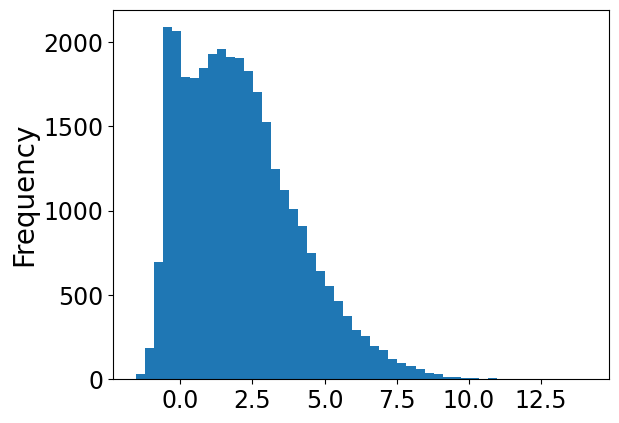

In [ ]:
FIXATION_LABEL = ['PURS', 'FIXA']
run_id = 8
saliency_df = get_saliency_df(run_id=run_id)
resample_fs = 25 # 1000Hz以下
fs_ms = 1000 / resample_fs # ms

# create subject list
subj_list = []
for sub_id in SUBJECT_IDS:
    eyetrack = get_eyetrack_df(sub_id, run_id)
    eyetrack_fixations = eyetrack[eyetrack['label'].isin(FIXATION_LABEL)]
    xs, ys, ts = [], [], []
    for i, row in eyetrack_fixations.iterrows():
        duration = row['duration'] * 1000
        t_Start = row['onset'] * 1000
        t_End = t_Start + duration
        n_points = int(np.ceil(duration / fs_ms))
        t = np.linspace(t_Start, t_End, n_points)
        if n_points > 1:
           x = np.interp(t, [t_Start, t_End], [row['start_x'], row['end_x']])
           y = np.interp(t, [t_Start, t_End], [row['start_y'], row['end_y']])
        else:
           x = np.array([row['start_x']])
           y = np.array([row['start_y']])
        assert len(x) == len(y) == len(t), f"Length mismatch: {len(x)}, {len(y)}, {len(t)}"
        xs += x.tolist()
        ys += y.tolist()
        ts += t.tolist()
    subj_list.append(Samples(s=sub_id, x=np.array(xs), y=np.array(ys), t=np.array(ts)))

    # print('max duration:', duration.max(), 'min duration:', duration.min())
    print('subj:', sub_id, 'n_fixations:', len(eyetrack_fixations), 'n_points:', len(xs))

win_ms = 500
step_ms = win_ms / 2
sigma_x = 33.3 # 視野角の半径100の1/3
sigma_y = 33.3 # 視野角の半径100の1/3
sigma_t = fs_ms * 4 # 4フレーム分の時間幅

print('Computing NSS scores with parameters:')
print(f'win_ms: {win_ms}, step_ms: {step_ms}, sigma_x: {sigma_x}, sigma_y: {sigma_y}, sigma_t: {sigma_t}')
df, meta = nss_time_extended(
    subj_list,
    sigma_x=sigma_x, sigma_y=sigma_y, sigma_t=sigma_t,
    # win_ms=225.0, step_ms=75.0,
    win_ms=win_ms, step_ms=step_ms,
    mc_probes=4000, mc_margin=(30, 30, 75.0), seed=0
)
df.to_csv(f'/home/kazu/shared_response/results/20251103/check_nss_saliency_run{run_id}_win{int(win_ms)}_step{int(step_ms)}_{sigma_x}_{sigma_y}_{sigma_t}.csv', index=False)
df['nss'].plot.hist(bins=50)

In [ ]:
def find_idx_of_specific_onset_offset(df, start, end, offset=False)->np.ndarray:
    onsets = df['t0'].values
    if offset:
        offsets = df['t1'].values
        idx = np.where((start <= offsets) & (offsets<=end))[0]
        # idx = np.where((start <= onsets) & (offsets<=end))[0]

    else:
        idx = np.where((start <= onsets) & (onsets<=end))[0]
    return idx

def alignment2VOLUME(df:pd.DataFrame, run_id:int, agg:str='sum')->pd.DataFrame:
    num_sample_per_run = RUN_VOLUMES[run_id-1]
    columns = list(df.columns)
    new_df = {col:[] for col in columns}
    for i in range(num_sample_per_run):
        onset = i * TR
        offset = onset + TR
        idx = find_idx_of_specific_onset_offset(df, onset, offset)
        if agg == 'sum':
            agg_df = df.iloc[idx].sum()
        elif agg == 'mean':
            agg_df = df.iloc[idx].mean()
        else:
            raise ValueError('agg should be sum or mean')
        for col in columns:
            new_df[col].append(agg_df[col])
    new_df = pd.DataFrame(new_df)
    return new_df

sbj_df_list = {
    sbj_id: [] for sbj_id in SUBJECT_IDS
}
for run_id in RUN_IDS:
    original_df = pd.read_csv(f'/home/kazu/shared_response/results/20251103/check_nss_saliency_run{run_id}_win{int(win_ms)}_step{int(step_ms)}_{sigma_x}_{sigma_y}_{sigma_t}.csv')

    for s, sbj_id in enumerate((SUBJECT_IDS)):
        sbj_df = original_df[original_df['subject'] == s]
        print(f'sbj{sbj_id}', sbj_df.columns)
        sbj_df.dropna(inplace=True, axis=0)
        sbj_df['t0'] = sbj_df['t0'] / 1000.0
        sbj_df['t1'] = sbj_df['t1'] / 1000.0
        aligned_df = alignment2VOLUME(sbj_df, run_id=run_id, agg='mean')
        sbj_df_list[sbj_id].append(aligned_df)
for sbj_id in SUBJECT_IDS:
    sbj_df_list[sbj_id] = pd.concat(sbj_df_list[sbj_id], axis=0, ignore_index=True)



sbj01 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj02 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_49223/3719763269.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_49223/3719763269.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_49223/3719763269.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

sbj03 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj04 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_49223/3719763269.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_49223/3719763269.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_49223/3719763269.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

sbj06 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj10 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


...

/tmp/ipykernel_49223/3719763269.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_49223/3719763269.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_49223/3719763269.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

sbj16 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj17 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_49223/3719763269.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_49223/3719763269.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_49223/3719763269.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

sbj18 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj19 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_49223/3719763269.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_49223/3719763269.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_49223/3719763269.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

In [82]:
sbj_df_list['01']

,t0,t1,subject,nss,n_test_samples
0,1.0,1.5,0.0,1.088909,11.444444
1,3.0,3.5,0.0,1.918583,12.888889
2,5.0,5.5,0.0,0.440454,10.555556
3,7.0,7.5,0.0,2.768755,12.000000
4,9.0,9.5,0.0,3.274710,13.000000
...,...,...,...,...,...
3594,667.0,667.5,0.0,1.682878,12.888889
3595,669.0,669.5,0.0,2.912677,13.222222
3596,671.0,671.5,0.0,1.285829,11.777778
3597,672.5,673.0,0.0,-0.618977,12.800000


In [57]:
eyemovement_q = 0.5
saliency_q = 0.9
gaze_shift_label = ['FIXA', 'PURS']
use_large_cnt = False
if use_large_cnt:
    lc_str = '_large'
else:
    lc_str = ''

prefix_dir = '../'

saliency_dir = os.path.join(prefix_dir, SAVE_ROOT, 'saliency', 'deepgaze2e_predict')
eyemovement_dir = os.path.join(prefix_dir, EYEMOVE_ROOT)
sal_df_sbj = {}
eye_df_sbj = {}
for sbj_id in SUBJECT_IDS:
    saliency_eyetrack_path = os.path.join(prefix_dir, SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                        f'{sbj_id}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
    if os.path.exists(saliency_eyetrack_path):
        print(f'{saliency_eyetrack_path} is already exist')
        saliency_eyetrack_df = pd.read_csv(saliency_eyetrack_path)
        for label in ['max_shift_norm', 'avg_shift_norm']:
            if f'SACC_cnt_with{lc_str}_lower_sal_{label}' in saliency_eyetrack_df.columns:
                saliency_eyetrack_df = saliency_eyetrack_df.rename(columns={f'SACC_cnt_with{lc_str}_lower_sal_{label}':f'SACC_cnt{lc_str}_with_lower_sal_{label}'})
    else:
        os.makedirs(os.path.dirname(saliency_eyetrack_path), exist_ok=True)
        print('saliency_eyetrack_df is not exist. Creating...')
        saliency_eyetrack_df_list = []
        idx_offsets = np.cumsum([0] + RUN_VOLUMES)
        for run_id in tqdm(RUN_IDS):
            saliency_csv_file_path = os.path.join(prefix_dir, saliency_dir, f'segment{run_id}.csv')
            original_eyetrack_path = os.path.join(prefix_dir, eyemovement_dir,  f'sub-{sbj_id}/sub-{sbj_id}_task-movie_run-{run_id}_events.tsv')
            # get saliency and eyemovement
            saliency_df, original_eyetrack_df = read_csvs(saliency_csv_file_path, original_eyetrack_path,
                                                        gaze_shift_label, video_width=MOVIE_WIDTH,
                                                        video_height=MOVIE_HEIGHT, fps=MOVIE_FPS)
            original_eyetrack_df['power'] = original_eyetrack_df['diff_x']**2 + original_eyetrack_df['diff_y']**2
            # time alignment eyetracking data to saliency data
            saliency_eyetrack_df = sacc_cnt_shift_relation_df(saliency_df,
                                                            original_eyetrack_df,
                                                            gaze_shift_label,
                                                            eyemovement_q, have_duration=False)
            # cnt sal with saliency
            saliency_eyetrack_df = count_gaze_shift_with_saliency(saliency_eyetrack_df, saliency_q)
            # time alignment saliency_eyetrack_df to VOLUME
            saliency_eyetrack_df = alignment2VOLUME_Original(saliency_eyetrack_df, run_id, agg='sum')
            assert len(saliency_eyetrack_df) == RUN_VOLUMES[run_id-1], f'len(saliency_df)={len(saliency_eyetrack_df)}, RUN_VOLUMES[run_id-1]={RUN_VOLUMES[run_id-1]}'
            idx_in_exp = list(np.arange(RUN_VOLUMES[run_id-1]) + idx_offsets[run_id-1])
            saliency_eyetrack_df['idx_in_exp'] = idx_in_exp
            saliency_eyetrack_df_list.append(saliency_eyetrack_df)
        saliency_eyetrack_df = pd.concat(saliency_eyetrack_df_list, axis=0)

    eyetrack_df_list = []
    for run_id in tqdm(RUN_IDS):
        idx_offsets = np.cumsum([0] + RUN_VOLUMES)
        original_eyetrack_path = os.path.join(prefix_dir ,EYEMOVE_ROOT,  f'sub-{sbj_id}/sub-{sbj_id}_task-movie_run-{run_id}_events.tsv')
        # get eyemovement
        _, original_eyetrack_df = read_csvs(None, original_eyetrack_path,
                                                    gaze_shift_label, video_width=MOVIE_WIDTH,
                                                    video_height=MOVIE_HEIGHT, fps=MOVIE_FPS)
        original_eyetrack_df.drop(columns=['label'], inplace=True)
        original_eyetrack_df = alignment2VOLUME_Original(original_eyetrack_df, run_id, agg='mean')
        assert len(original_eyetrack_df) == RUN_VOLUMES[run_id-1], f'len(original_eyetrack_Df_df)={len(original_eyetrack_df)}, RUN_VOLUMES[run_id-1]={RUN_VOLUMES[run_id-1]}'
        idx_in_exp = list(np.arange(RUN_VOLUMES[run_id-1]) + idx_offsets[run_id-1])
        original_eyetrack_df['idx_in_exp'] = idx_in_exp
        eyetrack_df_list.append(original_eyetrack_df)

    eyetrack_df = pd.concat(eyetrack_df_list, axis=0)
    eyetrack_df.set_index('idx_in_exp', inplace=True)

    sal_df_sbj[sbj_id] = saliency_eyetrack_df
    eye_df_sbj[sbj_id] = eyetrack_df

../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/01-FIXA_PURS_q0.5-sal_q0.9.csv is already exist


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:01<00:00,  7.85it/s]


../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/02-FIXA_PURS_q0.5-sal_q0.9.csv is already exist


100%|██████████| 8/8 [00:01<00:00,  7.97it/s]


...

100%|██████████| 8/8 [00:01<00:00,  7.95it/s]


../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/18-FIXA_PURS_q0.5-sal_q0.9.csv is already exist


100%|██████████| 8/8 [00:01<00:00,  7.99it/s]


../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/19-FIXA_PURS_q0.5-sal_q0.9.csv is already exist


100%|██████████| 8/8 [00:00<00:00,  8.01it/s]


In [81]:
original_eyetrack_df

,onset,duration,start_x,start_y,end_x,end_y,amp,peak_vel,med_vel,avg_vel,diff_x,diff_y,velocity_x,velocity_y,idx_in_exp
0,0.594857,0.269000,580.771429,206.514286,578.257143,208.185714,0.128286,27.527857,8.412000,9.346571,-2.514286,1.671429,-35.440409,-9.806382,3261
1,2.913167,0.401833,690.150000,247.216667,691.666667,251.433333,0.258167,30.292000,9.513833,10.769667,1.516667,4.216667,79.050614,4.396879,3262
2,5.151750,0.350000,666.200000,282.525000,671.275000,281.050000,0.276750,35.873250,8.838750,9.668250,5.075000,-1.475000,19.965882,-11.075594,3263
3,6.996727,0.166182,559.954545,274.609091,566.754545,277.036364,0.259818,27.801364,7.774636,9.003364,6.800000,2.427273,43.605030,25.937916,3264
4,8.411000,0.799250,775.175000,250.025000,767.375000,246.175000,0.557750,34.114500,9.773750,11.034500,-7.800000,-3.850000,90.387334,-29.263152,3265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,667.055222,0.219444,677.211111,108.866667,684.366667,117.488889,0.698556,26.305111,8.838333,9.615778,7.155556,8.622222,16.373917,20.392552,3594
334,669.045909,0.154182,735.418182,188.354545,740.109091,191.863636,0.353909,30.093727,10.173909,11.230273,4.690909,3.509091,66.150111,24.176527,3595
335,670.905462,0.142385,554.207692,170.592308,556.407692,183.992308,0.716077,23.213538,9.433385,9.899462,2.200000,13.400000,-26.244890,103.902505,3596
336,672.652600,0.265400,585.520000,340.920000,575.980000,344.080000,0.197600,30.035800,10.604000,11.439800,-9.540000,3.160000,-66.562651,1.762120,3597


2728 815
Index(['iou_q', 'saliency_TR_q', 'iou_th', 'sal_upper_th', 'sal_lower_th'], dtype='object')
424.8501357814248 1057.7329848865415
nss_all_sbj shape: (12, 3599)
mean_nss vs saliency -0.2398670035618742


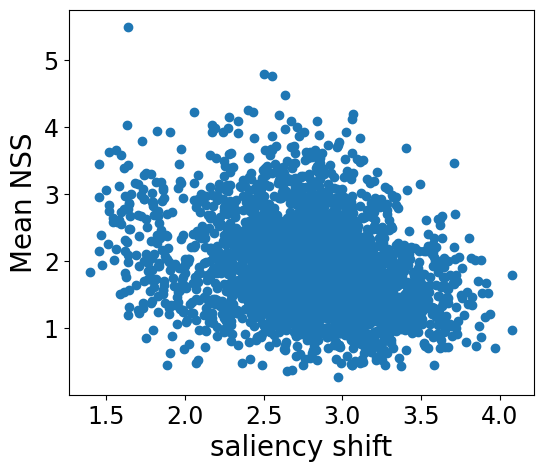

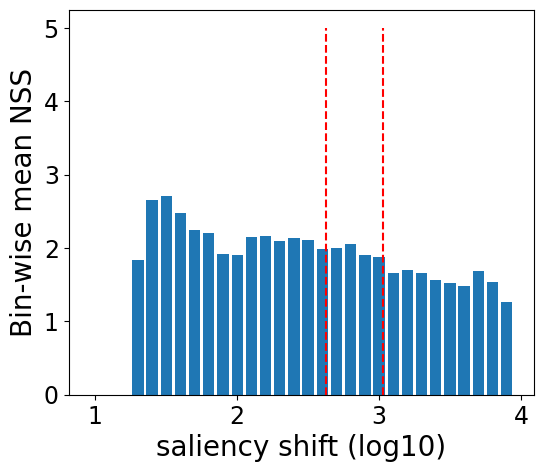

lower: 870 upper: 866


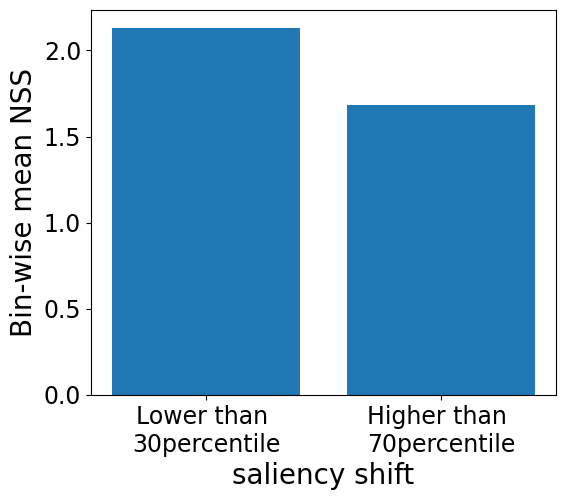

In [72]:
saliency_shift = saliency_eyetrack_df['avg_shift_norm'].to_numpy()

non_overlap_train_indices, non_overlap_test_indices = get_non_overlap_indices_for_concatenate_data('segment', jupyter=True)
print(len(non_overlap_train_indices), len(non_overlap_test_indices))

grand_quantile_path = '../../../results/voluntary_fixation/behavior/grand_quantiles.csv'
grand_quantiles_df = pd.read_csv(grand_quantile_path)
print(grand_quantiles_df.columns)
target_th = grand_quantiles_df.query('iou_q==0.5' and 'saliency_TR_q==0.7')
sal_upper_th = target_th['sal_upper_th'].values[0]
sal_lower_th = target_th['sal_lower_th'].values[0]
print(sal_lower_th, sal_upper_th)



nss_all_sbj = np.stack([sbj_df_list[sbj_id]['nss'].to_numpy() for sbj_id in SUBJECT_IDS], axis=0)
print('nss_all_sbj shape:', nss_all_sbj.shape)  # (num_subjects, num_timepoints)

# 全被験者存在するsampleのインデックスを取得
mean_nss = []
saliency_shift_valid = []
for i in range(len(nss_all_sbj[0])):
    if np.isnan(nss_all_sbj[:, i]).any():
        continue
    mean_nss.append(np.mean(nss_all_sbj[:, i]))
    saliency_shift_valid.append(saliency_shift[i])
print('mean_nss vs saliency', np.corrcoef(mean_nss, saliency_shift_valid)[0, 1])
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
ax.scatter(np.log10(saliency_shift_valid), mean_nss)
ax.set_xlabel('saliency shift')
ax.set_ylabel('Mean NSS')
plt.show()


mean_nss = np.array(mean_nss)
saliency_shift_valid_log = np.log10(np.array(saliency_shift_valid))
sal_interval = 0.1
max_sal = int(np.round(np.max(saliency_shift_valid_log)))
min_sal = int(np.round(np.min(saliency_shift_valid_log)))
num_bins = int((max_sal - min_sal) / sal_interval)
rets_nss = [0 for i in range(num_bins)]


bin_Starts = []
for i in range(num_bins):
    s = min_sal + i * sal_interval
    bin_Starts.append(s)
    idx = np.where((saliency_shift_valid_log >= s) & (saliency_shift_valid_log < s+sal_interval))[0]
    if len(idx) == 0:
        continue
    rets_nss[i] = mean_nss[idx]


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
ax.bar(bin_Starts, [np.mean(x) for x in rets_nss], width=0.8*sal_interval)
ax.vlines(np.log10(sal_lower_th), ymin=0, ymax=5,color='red', linestyle='--')
ax.vlines(np.log10(sal_upper_th), ymin=0, ymax=5,color='red', linestyle='--')
ax.set_xlabel('saliency shift (log10)')
ax.set_ylabel('Bin-wise mean NSS')
plt.show()



rets_nss = [0,0]
# below lower th
lower_idx = np.where((saliency_shift_valid <= sal_lower_th))[0]
# above upper th
upper_idx = np.where((saliency_shift_valid >= sal_upper_th))[0]
print('lower:', len(lower_idx), 'upper:', len(upper_idx))
rets_nss[0] = mean_nss[lower_idx]
rets_nss[1] = mean_nss[upper_idx]
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
axes.bar([0, 1], [np.nanmean(x) for x in rets_nss], width=0.8)
axes.set_xlabel('saliency shift')
axes.set_ylabel('Bin-wise mean NSS')
axes.set_xticks([0, 1])
axes.set_xticklabels(['Lower than \n30percentile', 'Higher than \n70percentile'])
plt.show()



2728 815
Index(['iou_q', 'saliency_TR_q', 'iou_th', 'sal_upper_th', 'sal_lower_th'], dtype='object')
424.8501357814248 1057.7329848865415
nss_all_sbj shape: (12, 3599)
mean_nss vs saliency -0.27508153109889205


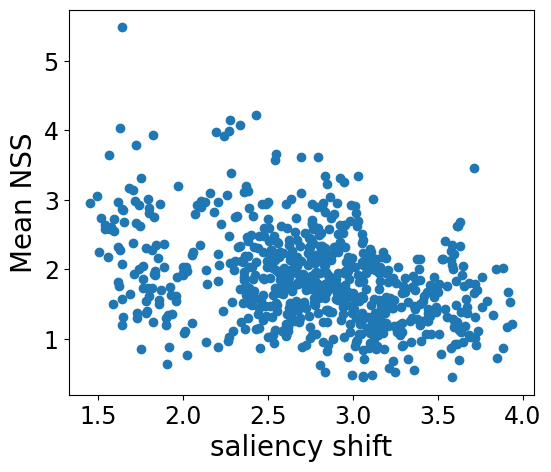

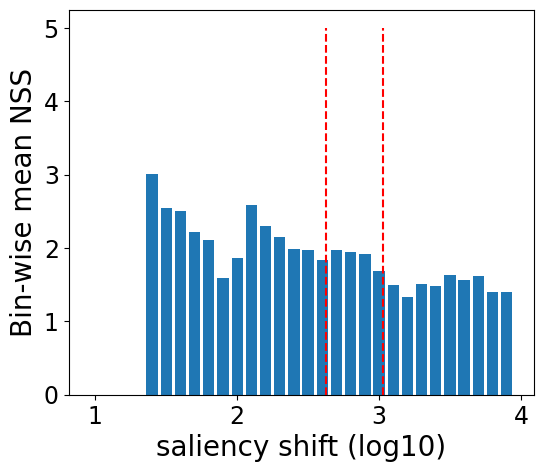

lower: 251 upper: 215


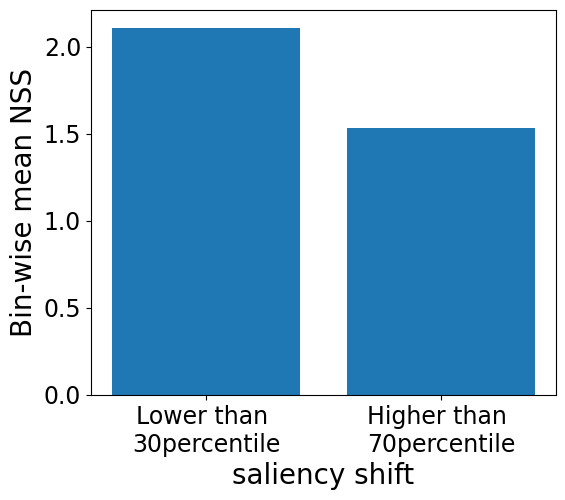

In [74]:
# testデータのみ
saliency_shift = saliency_eyetrack_df['avg_shift_norm'].to_numpy()

non_overlap_train_indices, non_overlap_test_indices = get_non_overlap_indices_for_concatenate_data('segment', jupyter=True)
print(len(non_overlap_train_indices), len(non_overlap_test_indices))

grand_quantile_path = '../../../results/voluntary_fixation/behavior/grand_quantiles.csv'
grand_quantiles_df = pd.read_csv(grand_quantile_path)
print(grand_quantiles_df.columns)
target_th = grand_quantiles_df.query('iou_q==0.5' and 'saliency_TR_q==0.7')
sal_upper_th = target_th['sal_upper_th'].values[0]
sal_lower_th = target_th['sal_lower_th'].values[0]
print(sal_lower_th, sal_upper_th)



nss_all_sbj = np.stack([sbj_df_list[sbj_id]['nss'].to_numpy() for sbj_id in SUBJECT_IDS], axis=0)
print('nss_all_sbj shape:', nss_all_sbj.shape)  # (num_subjects, num_timepoints)

nss_all_sbj = nss_all_sbj[:, non_overlap_test_indices]
saliency_shift = saliency_shift[non_overlap_test_indices]

# 全被験者存在するsampleのインデックスを取得
mean_nss = []
saliency_shift_valid = []
for i in range(len(nss_all_sbj[0])):
    if np.isnan(nss_all_sbj[:, i]).any():
        continue
    mean_nss.append(np.mean(nss_all_sbj[:, i]))
    saliency_shift_valid.append(saliency_shift[i])
print('mean_nss vs saliency', np.corrcoef(mean_nss, saliency_shift_valid)[0, 1])
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
ax.scatter(np.log10(saliency_shift_valid), mean_nss)
ax.set_xlabel('saliency shift')
ax.set_ylabel('Mean NSS')
plt.show()


mean_nss = np.array(mean_nss)
saliency_shift_valid_log = np.log10(np.array(saliency_shift_valid))
sal_interval = 0.1
max_sal = int(np.round(np.max(saliency_shift_valid_log)))
min_sal = int(np.round(np.min(saliency_shift_valid_log)))
num_bins = int((max_sal - min_sal) / sal_interval)
rets_nss = [0 for i in range(num_bins)]


bin_Starts = []
for i in range(num_bins):
    s = min_sal + i * sal_interval
    bin_Starts.append(s)
    idx = np.where((saliency_shift_valid_log >= s) & (saliency_shift_valid_log < s+sal_interval))[0]
    if len(idx) == 0:
        continue
    rets_nss[i] = mean_nss[idx]


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
ax.bar(bin_Starts, [np.mean(x) for x in rets_nss], width=0.8*sal_interval)
ax.vlines(np.log10(sal_lower_th), ymin=0, ymax=5,color='red', linestyle='--')
ax.vlines(np.log10(sal_upper_th), ymin=0, ymax=5,color='red', linestyle='--')
ax.set_xlabel('saliency shift (log10)')
ax.set_ylabel('Bin-wise mean NSS')
plt.show()



rets_nss = [0,0]
# below lower th
lower_idx = np.where((saliency_shift_valid <= sal_lower_th))[0]
# above upper th
upper_idx = np.where((saliency_shift_valid >= sal_upper_th))[0]
print('lower:', len(lower_idx), 'upper:', len(upper_idx))
rets_nss[0] = mean_nss[lower_idx]
rets_nss[1] = mean_nss[upper_idx]
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
axes.bar([0, 1], [np.nanmean(x) for x in rets_nss], width=0.8)
axes.set_xlabel('saliency shift')
axes.set_ylabel('Bin-wise mean NSS')
axes.set_xticks([0, 1])
axes.set_xticklabels(['Lower than \n30percentile', 'Higher than \n70percentile'])
plt.show()



In [80]:
nss_all_sbj

array([[ 1.80292763,  1.08497689,  2.9447008 , ...,  1.28582949,
        -0.61897719,         nan],
       [ 1.61207267,  1.3299865 ,  2.65119915, ...,  3.09062348,
         3.33416141,         nan],
       [ 1.98341345,  1.20372779,  3.2985257 , ...,  2.73713482,
         0.7476943 ,         nan],
       ...,
       [ 0.9663176 ,  1.65819303,  0.9863462 , ...,  2.60343029,
         0.05414852,         nan],
       [ 1.89833137,  1.30956512,  4.66660084, ...,  2.07099255,
         1.6394469 ,         nan],
       [ 0.19844048, -0.27991725,  3.64151347, ...,  2.54100869,
         3.32867137,         nan]])

Index(['Unnamed: 0', 'idx_in_run', 'idx_in_exp', 'iou', 'run_id'], dtype='object') 3599
2728 815
Index(['iou_q', 'saliency_TR_q', 'iou_th', 'sal_upper_th', 'sal_lower_th'], dtype='object')
424.8501357814248 1057.7329848865415
nss_all_sbj shape: (12, 3599)
mean_nss vs saliency -0.18934233482762355


/home/kazu/envs/srm_env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kazu/envs/srm_env/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


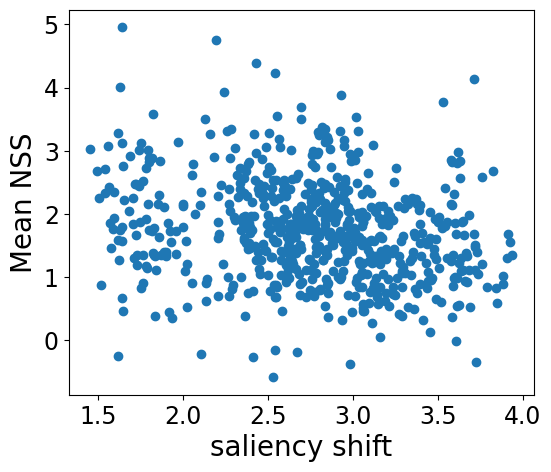

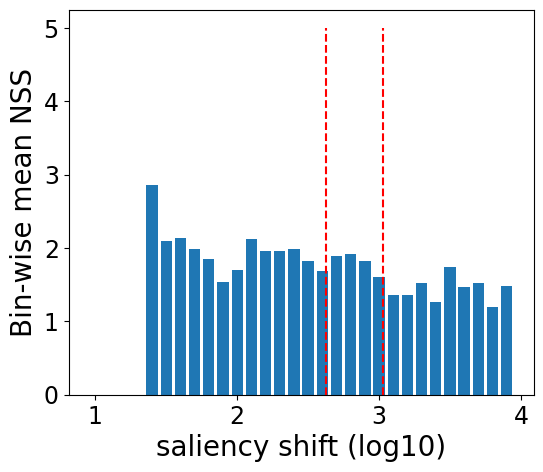

lower: 245 upper: 212


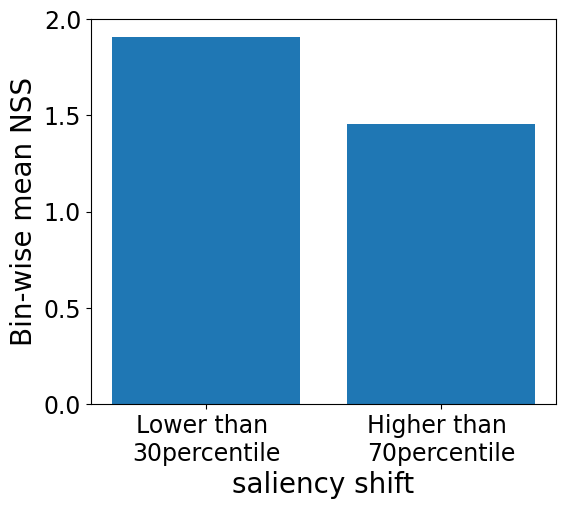

t値: 6.115790265514403
p値: 2.082202867211677e-09


In [79]:
iou_th = 0.31246855875
sal_lower_th = target_th['sal_lower_th'].values[0]
iou_dfs = {}
for sbj in SUBJECT_IDS:
    iou_path = os.path.join('../', SAVE_ROOT, 'mask', f'resolution{TR}-start0', 'iou',
                                    f'sub-{sbj}.csv')
    iou_df = pd.read_csv(iou_path)
    iou_dfs[sbj] = iou_df
print(iou_df.columns, len(iou_df))

iou_flag = np.zeros([len(SUBJECT_IDS), len(iou_df)])
for i, sbj in enumerate(SUBJECT_IDS):
    iou_df = iou_dfs[sbj]
    iou_flag[i, :] = iou_df['iou'] <= iou_th

iou_flag_across_sbj = np.all(iou_flag, axis=0)


# testデータのみ
saliency_shift = saliency_eyetrack_df['avg_shift_norm'].to_numpy()

non_overlap_train_indices, non_overlap_test_indices = get_non_overlap_indices_for_concatenate_data('segment', jupyter=True)
print(len(non_overlap_train_indices), len(non_overlap_test_indices))

grand_quantile_path = '../../../results/voluntary_fixation/behavior/grand_quantiles.csv'
grand_quantiles_df = pd.read_csv(grand_quantile_path)
print(grand_quantiles_df.columns)
target_th = grand_quantiles_df.query('iou_q==0.5' and 'saliency_TR_q==0.7')
sal_upper_th = target_th['sal_upper_th'].values[0]
sal_lower_th = target_th['sal_lower_th'].values[0]
print(sal_lower_th, sal_upper_th)



nss_all_sbj = np.stack([sbj_df_list[sbj_id]['nss'].to_numpy() for sbj_id in SUBJECT_IDS], axis=0)
print('nss_all_sbj shape:', nss_all_sbj.shape)  # (num_subjects, num_timepoints)

nss_all_sbj = nss_all_sbj[:, non_overlap_test_indices]
saliency_shift = saliency_shift[non_overlap_test_indices]
iou_flag_split = iou_flag[:, non_overlap_test_indices]

# 全被験者存在するsampleのインデックスを取得
mean_nss = []
saliency_shift_valid = []
for i in range(len(nss_all_sbj[0])):
    if np.isnan(nss_all_sbj[:, i]).any():
        continue
    moving_gaze_sbj_ids = np.where(iou_flag_split[:, i])[0]
    mean_nss_val = np.mean(nss_all_sbj[moving_gaze_sbj_ids, i])
    if np.isnan(mean_nss_val):
        continue
    mean_nss.append(mean_nss_val)
    saliency_shift_valid.append(saliency_shift[i])
print('mean_nss vs saliency', np.corrcoef(mean_nss, saliency_shift_valid)[0, 1])
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
ax.scatter(np.log10(saliency_shift_valid), mean_nss)
ax.set_xlabel('saliency shift')
ax.set_ylabel('Mean NSS')
plt.show()


mean_nss = np.array(mean_nss)
saliency_shift_valid_log = np.log10(np.array(saliency_shift_valid))
sal_interval = 0.1
max_sal = int(np.round(np.max(saliency_shift_valid_log)))
min_sal = int(np.round(np.min(saliency_shift_valid_log)))
num_bins = int((max_sal - min_sal) / sal_interval)
rets_nss = [0 for i in range(num_bins)]


bin_Starts = []
for i in range(num_bins):
    s = min_sal + i * sal_interval
    bin_Starts.append(s)
    idx = np.where((saliency_shift_valid_log >= s) & (saliency_shift_valid_log < s+sal_interval))[0]
    if len(idx) == 0:
        continue
    rets_nss[i] = mean_nss[idx]


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
ax.bar(bin_Starts, [np.mean(x) for x in rets_nss], width=0.8*sal_interval)
ax.vlines(np.log10(sal_lower_th), ymin=0, ymax=5,color='red', linestyle='--')
ax.vlines(np.log10(sal_upper_th), ymin=0, ymax=5,color='red', linestyle='--')
ax.set_xlabel('saliency shift (log10)')
ax.set_ylabel('Bin-wise mean NSS')
plt.show()



rets_nss = [0,0]
# below lower th
lower_idx = np.where((saliency_shift_valid <= sal_lower_th))[0]
# above upper th
upper_idx = np.where((saliency_shift_valid >= sal_upper_th))[0]
print('lower:', len(lower_idx), 'upper:', len(upper_idx))
rets_nss[0] = mean_nss[lower_idx]
rets_nss[1] = mean_nss[upper_idx]
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
axes.bar([0, 1], [np.nanmean(x) for x in rets_nss], width=0.8)
axes.set_xlabel('saliency shift')
axes.set_ylabel('Bin-wise mean NSS')
axes.set_xticks([0, 1])
axes.set_xticklabels(['Lower than \n30percentile', 'Higher than \n70percentile'])
plt.show()


from scipy import stats
t_stat, p_val = stats.ttest_ind(rets_nss[0], rets_nss[1], equal_var=False)

print("t値:", t_stat)
print("p値:", p_val)

In [30]:
sbj_df = original_df[original_df['subject'] == sbj_id]
sbj_df


,t0,t1,subject,nss,n_test_samples
11,0.0,500.0,11,1.787185,13
23,250.0,750.0,11,5.044868,12
35,500.0,1000.0,11,5.731383,13
47,750.0,1250.0,11,3.457338,14
59,1000.0,1500.0,11,3.243743,13
...,...,...,...,...,...
46787,974500.0,975000.0,11,1.668432,13
46799,974750.0,975250.0,11,0.179834,14
46811,975000.0,975500.0,11,0.757992,14
46823,975250.0,975750.0,11,3.445310,13


In [28]:
original_df


,t0,t1,subject,nss,n_test_samples
0,0.0,500.0,0,1.971143,15
1,0.0,500.0,1,-0.606873,13
2,0.0,500.0,2,NaN,0
3,0.0,500.0,3,3.958936,3
4,0.0,500.0,4,1.047818,13
...,...,...,...,...,...
46831,975500.0,976000.0,7,-0.484147,13
46832,975500.0,976000.0,8,NaN,0
46833,975500.0,976000.0,9,4.105613,13
46834,975500.0,976000.0,10,1.862382,13


In [ ]:
FIXATION_LABEL = ['PURS', 'FIXA']
run_id = 4
saliency_df = get_saliency_df(run_id=run_id)
resample_fs = 250 # 1000Hz以下
fs_ms = 1000 / resample_fs # ms

# create subject list
subj_list = []
for sub_id in SUBJECT_IDS:
    eyetrack = get_eyetrack_df(sub_id, run_id)
    eyetrack_fixations = eyetrack[eyetrack['label'].isin(FIXATION_LABEL)]
    duration = eyetrack_fixations['duration'].to_numpy() * 1000
    xs = (eyetrack_fixations['start_x'].to_numpy() + eyetrack_fixations['end_x'].to_numpy())/2 # これはresample FSに合わせて補完すべき
    ys = (eyetrack_fixations['start_y'].to_numpy() + eyetrack_fixations['end_y'].to_numpy())/2 # これはresample FSに合わせて補完すべき
    ts = eyetrack_fixations['onset'].to_numpy() * 1000 # ms unit # これはresample FSに合わせて補完すべき
    subj_list.append(Samples(s=sub_id, x=xs, y=ys, t=ts))

win_ms = 500
step_ms = win_ms / 2
sigma_x = 33.3 # 視野角の半径100の1/3
sigma_y = 33.3 # 視野角の半径100の1/3
sigma_t = fs_ms * 4 # 4フレーム分の時間幅

df, meta = nss_time_extended(
    subj_list,
    sigma_x=sigma_x, sigma_y=sigma_y, sigma_t=sigma_t,
    # win_ms=225.0, step_ms=75.0,
    win_ms=500.0, step_ms=75.0,
    mc_probes=4000, mc_margin=(3.0, 3.0, 75.0), seed=0
)
df.to_csv(f'/home/kazu/shared_response/results/20251103/check_nss_saliency_run{run_id}_win{int(win_ms)}_step{int(step_ms)}.csv', index=False)